In [3]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go

import chinese_calendar as calendar
from datetime import timedelta, date

import warnings
warnings.filterwarnings('ignore')

In [4]:
# 设置 rcParams 默认值
import matplotlib
from matplotlib import font_manager

preferred_fonts = [
    "Microsoft YaHei", "PingFang SC", "Hiragino Sans GB", "Heiti SC",
    "Songti SC", "Arial Unicode MS", "SimHei", "Noto Sans CJK SC",
    "DejaVu Sans",
]
available_fonts = {font.name for font in font_manager.fontManager.ttflist}
plot_font = next((font for font in preferred_fonts if font in available_fonts), "DejaVu Sans")
matplotlib.rc("font", family=plot_font)

sns.set_style("whitegrid")
plt.rc("figure", autolayout=True, figsize=(11, 5))
plt.rc("axes",
        labelweight="bold", # 标签粗细
        labelsize="large", # 标签字体
        titleweight="bold", # 标题粗细
        titlesize=16, # 标题字体
        titlepad=10,
      )
plt.rcParams['font.sans-serif'] = [plot_font]
plt.rcParams['axes.unicode_minus'] = False

In [5]:
# df_raw = pd.read_csv("./CSLB-daily.csv") 
df_raw = pd.read_csv("Essentiale-daily.csv") 
df_raw = df_raw.sort_values(["bizym", "transdate"])
df_raw["mtd_qty"] = df_raw.groupby("bizym")["qty"].cumsum()

# Preprocessing

In [6]:
# ============================================================
# 模块1：生成日历辅助表
# 对任意年月，生成该月每一天的工作日信息：
#   - is_workday：是否工作日（chinese_calendar 判断，含法定节假日和调休）
#   - wd_seq：月内第几个工作日（非工作日为 0）
#   - prev_workday：最近的上一个工作日日期（用于非工作日平台化处理）
# ============================================================

def build_calendar(year: int, month: int) -> pd.DataFrame:
    start = date(year, month, 1)
    if month == 12:
        end = date(year + 1, 1, 1) - timedelta(days=1)
    else:
        end = date(year, month + 1, 1) - timedelta(days=1)

    records = []
    wd_counter = 0
    prev_wd_date = None

    d = start
    while d <= end:
        is_wd = calendar.is_workday(d)
        if is_wd:
            wd_counter += 1
            prev_wd_date = d
        records.append({
            'transdate':    pd.Timestamp(d),
            'day_of_month': d.day,
            'is_workday':   is_wd,
            'wd_seq':       wd_counter if is_wd else 0,
            'prev_workday': pd.Timestamp(prev_wd_date) if prev_wd_date else None,
        })
        d += timedelta(days=1)

    return pd.DataFrame(records)

In [7]:
# ============================================================
# 模块2：数据预处理：缺失日期补全
# 必须在任何计算之前完成，原因：
#   - 原始数据可能缺失某些日期
# 处理逻辑：
#   - 以 build_calendar 为框架做左连接
#   - 缺失日期的 mtd_qty 用前向填充（= 上一天的累积量）
#   - 缺失日期的 qty 填 0
#   - 打印警告提示哪些日期被补全
# ============================================================

def preprocess(df: pd.DataFrame, warn: bool = True) -> pd.DataFrame:
    df = df.copy()
    df['transdate'] = pd.to_datetime(df['transdate'])

    filled_parts = []

    for ym, group in df.groupby('bizym'):
        year, month = ym // 100, ym % 100

        # 日历日期
        cal = build_calendar(year, month)

        merged = cal.merge(
            group[['transdate', 'qty', 'mtd_qty']],
            on='transdate', how='left'
        )

        # 缺失日期警告
        if warn:
            missing_dates = merged[merged['mtd_qty'].isna()]['transdate'].dt.date.tolist()
            if missing_dates:
                print(f"[警告] bizym={ym} 以下日期数据缺失，已自动补全：{missing_dates}")

        # mtd_qty 前向填充；月初若缺失则从 0 开始
        merged['mtd_qty'] = merged['mtd_qty'].ffill().fillna(0)
        merged['qty'] = merged['qty'].fillna(0)
        merged['bizym'] = ym

        # ============================================================
        # 非工作日量转移
        # 逻辑：非工作日若有qty，转移到后面最近工作日；
        #        若月内后面无工作日，则转移到前面最近工作日；
        #        非工作日qty抹0，最后重算mtd_qty
        # ============================================================
        workday_mask = merged['is_workday'] == 1
        workday_indices = merged.index[workday_mask].tolist()

        for idx in merged.index[~workday_mask]:
            qty_val = merged.at[idx, 'qty']
            if qty_val == 0:
                continue

            # 找后面最近的工作日
            next_wd = [i for i in workday_indices if i > idx]
            if next_wd:
                target_idx = next_wd[0]
            else:
                # 月内后面没有工作日，找前面最近的工作日
                prev_wd = [i for i in workday_indices if i < idx]
                if prev_wd:
                    target_idx = prev_wd[-1]
                else:
                    # 月内完全没有工作日（极端情况），量无处转移，保留原位
                    if warn:
                        print(f"[警告] bizym={ym} 月内无工作日，{merged.at[idx, 'transdate'].date()} 的qty={qty_val}无法转移")
                    continue

            merged.at[target_idx, 'qty'] += qty_val
            merged.at[idx, 'qty'] = 0

        # qty分布变化后重算mtd_qty
        merged['mtd_qty'] = merged['qty'].cumsum()

        filled_parts.append(
            merged[['bizym', 'transdate', 'qty', 'mtd_qty',
                     'day_of_month', 'is_workday', 'wd_seq', 'prev_workday']]
        )

    result = pd.concat(filled_parts, ignore_index=True)
    result = result.sort_values(['bizym', 'transdate']).reset_index(drop=True)
    return result

---

In [8]:
df = preprocess(df_raw)

[警告] bizym=202402 以下日期数据缺失，已自动补全：[datetime.date(2024, 2, 10), datetime.date(2024, 2, 11), datetime.date(2024, 2, 12)]
[警告] bizym=202602 以下日期数据缺失，已自动补全：[datetime.date(2026, 2, 16), datetime.date(2026, 2, 17)]


findfont: Failed to find font weight bold, now using 600.
findfont: Failed to find font weight bold, now using 600.


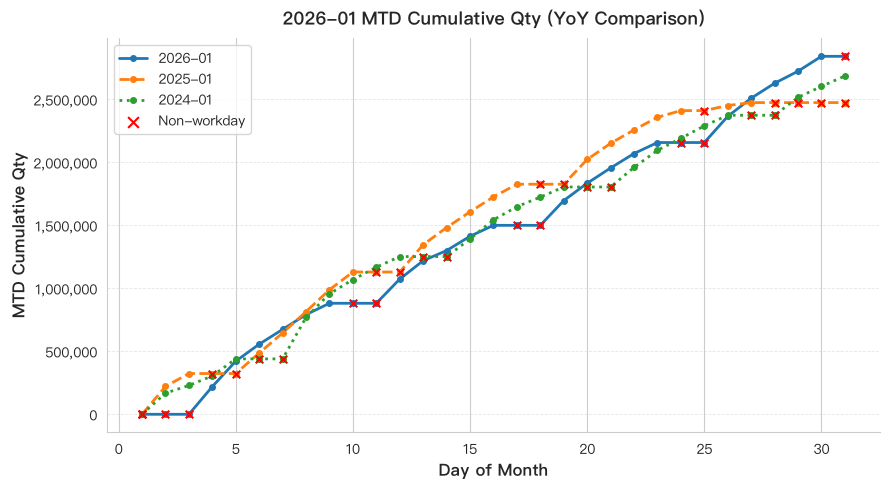

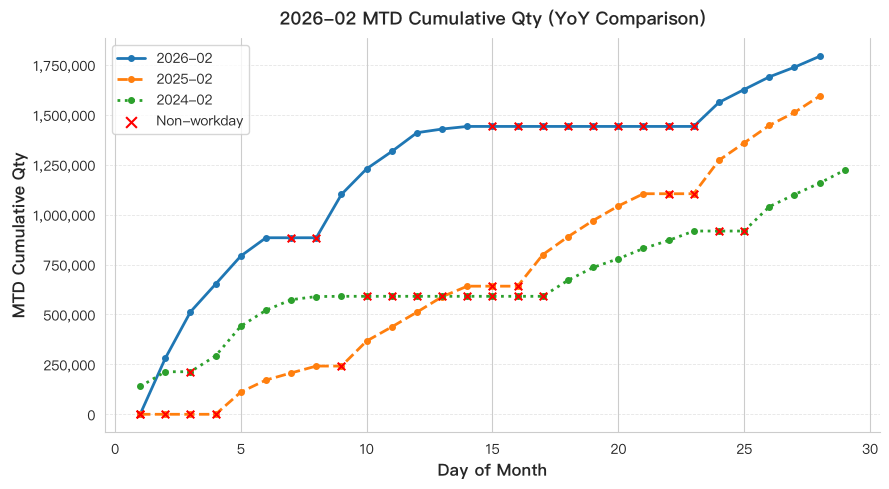

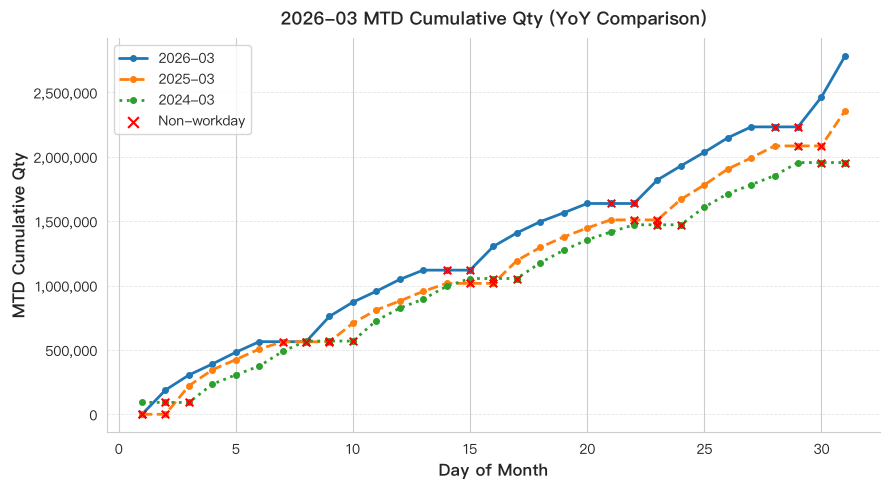

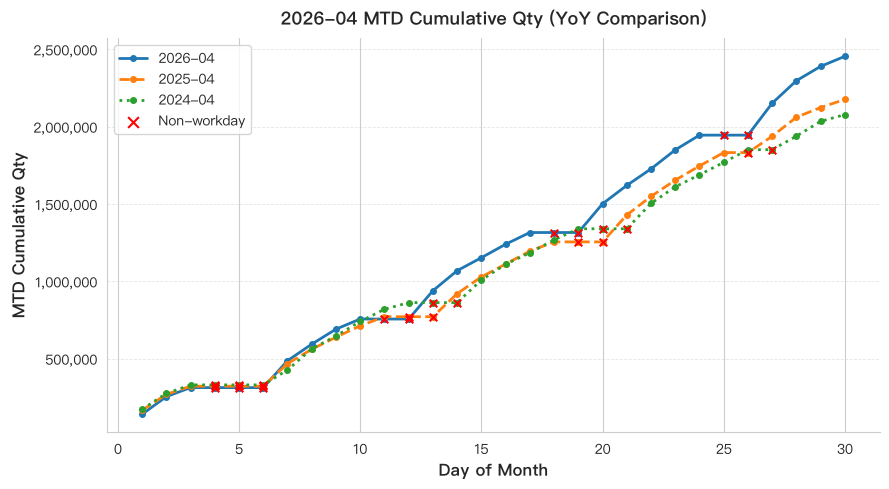

In [9]:
df_plot = df.copy()
df_plot['bizym'] = df_plot['bizym'].astype(str)

PLOT_START_YM = 202601

for ym in df_plot["bizym"].unique():
    year = int(ym[:4])
    month = ym[4:]
    
    # Only process from PLOT_START_YM onwards
    if int(ym) < PLOT_START_YM:
        continue
    
    # Calculate previous years
    ym_last_year = f"{year-1}{month}"
    ym_two_years_ago = f"{year-2}{month}"
    
    # Get data for current, last year, and two years ago
    sub_current = df_plot[df_plot["bizym"] == ym]
    sub_last_year = df_plot[df_plot["bizym"] == ym_last_year]
    sub_two_years = df_plot[df_plot["bizym"] == ym_two_years_ago]
    
    fig, ax = plt.subplots(figsize=(9, 5))
    
    # Plot current year
    ax.plot(sub_current["day_of_month"], sub_current["mtd_qty"], 
            linewidth=2, marker="o", markersize=4, label=f"{year}-{month}")
    
    # Plot last year if data exists
    if not sub_last_year.empty:
        ax.plot(sub_last_year["day_of_month"], sub_last_year["mtd_qty"], 
                linewidth=2, marker="o", markersize=4, label=f"{year-1}-{month}", linestyle="--")
    
    # Plot two years ago if data exists
    if not sub_two_years.empty:
        ax.plot(sub_two_years["day_of_month"], sub_two_years["mtd_qty"], 
                linewidth=2, marker="o", markersize=4, label=f"{year-2}-{month}", linestyle=":")
        
    # 标出非工作日（红叉），三个年份都标
    for sub in [sub_current, sub_last_year, sub_two_years]:
        if sub.empty:
            continue
        non_workdays = sub[~sub["is_workday"]]
        if not non_workdays.empty:
            ax.scatter(non_workdays["day_of_month"], non_workdays["mtd_qty"],
                       marker="x", color="red", s=30, linewidths=1.5,
                       zorder=5)

    # legend 只加一次红叉标签
    ax.scatter([], [], marker="x", color="red", s=60, linewidths=1.5, label="Non-workday")
    
    ax.set_title(f"{year}-{month} MTD Cumulative Qty (YoY Comparison)", fontsize=13, fontweight="bold")
    ax.set_xlabel("Day of Month")
    ax.set_ylabel("MTD Cumulative Qty")
    ax.xaxis.set_major_locator(mticker.MultipleLocator(5))
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))
    ax.grid(axis="y", linestyle="--", linewidth=0.6, alpha=0.5)
    ax.spines[["top", "right"]].set_visible(False)
    ax.legend(loc="upper left")

# Baseline

## Forecasting

In [10]:
# ============================================================
# A1：计算历史年份的工作日节奏比例
# 核心思路：
#   节奏比例[WD_n] = 第n个工作日当天的 mtd_qty / 该月最终总量
# 这条曲线描述"销量在月内如何分布"，剔除了年份间绝对量差异
# ============================================================

def calc_wd_rhythm(df: pd.DataFrame, bizym: int) -> pd.DataFrame:
    """
    返回指定年月的工作日节奏 DataFrame
    columns: wd_seq, rhythm（该工作日对应的累积占比，0~1）
    """
    month_df = df[df['bizym'] == bizym].copy()
    if month_df.empty:
        return pd.DataFrame(columns=['wd_seq', 'rhythm'])

    # 月末总量 = 最后一天的 mtd_qty
    total = month_df['mtd_qty'].iloc[-1]
    if total == 0 or pd.isna(total):
        return pd.DataFrame(columns=['wd_seq', 'rhythm'])

    # 只取工作日行
    wd_df = month_df[month_df['wd_seq'] > 0].copy()
    wd_df['rhythm'] = wd_df['mtd_qty'] / total

    return wd_df[['wd_seq', 'rhythm']].reset_index(drop=True)

In [11]:
def align_rhythm(
    src_rhythm: pd.Series,   # index=1~src_max_wd
    target_max_wd: int,
    extrapolate_wds: int = 3  # 用最后几个工作日的增量速率外推
) -> np.ndarray:
    """
    历史节奏对齐到目标工作日数：
    - 目标 = 历史：历史节奏
    - 目标 < 历史：PCHIP 插值压缩
    - 目标 > 历史：PCHIP 插值 + 末尾增量速率外推
    """
    from scipy.interpolate import PchipInterpolator

    src_max_wd = len(src_rhythm)
    src_vals = src_rhythm.values

    if src_max_wd == target_max_wd:
        return src_vals.copy()

    # 先用 PCHIP 插值到 src_max_wd 个点（索引对应 1~src_max_wd）
    x_old = np.arange(1, src_max_wd + 1, dtype=float)
    interp_fn = PchipInterpolator(x_old, src_vals)

    if target_max_wd < src_max_wd:
        # 压缩：直接插值
        x_new = np.linspace(1, src_max_wd, target_max_wd)
        aligned = interp_fn(x_new)
    else:
        # 拉伸：已知部分插值，超出部分外推
        # 已知部分：1~src_max_wd 映射到新序列的 1~src_max_wd 位置
        x_known = np.linspace(1, src_max_wd, src_max_wd)
        aligned_known = interp_fn(x_known)

        # 外推部分：用最后 extrapolate_wds 个工作日的平均增量速率
        tail_increments = np.diff(src_vals[-extrapolate_wds:])  # 最后几个增量
        avg_increment = float(np.mean(tail_increments))

        # 外推的工作日数
        n_extra = target_max_wd - src_max_wd
        extra_vals = np.array([
            aligned_known[-1] + avg_increment * (i + 1)
            for i in range(n_extra)
        ])
        # 节奏比例不能超过 1（月末占比上限）
        extra_vals = np.clip(extra_vals, aligned_known[-1], 1.0)

        aligned = np.concatenate([aligned_known, extra_vals])

    return np.clip(aligned, 0, 1)

In [12]:
# ============================================================
# A2：融合多年节奏，生成加权平均节奏曲线
# 如果历史年份的工作日总数与目标月不同（例如今年21个，去年22个），
# 通过插值把历史节奏映射到统一的 1~target_max_wd 空间
# 某年数据缺失时自动跳过，剩余权重重新归一化
# ============================================================
def blend_rhythm(
    df: pd.DataFrame,
    history_yms: list,
    weights: list,
    target_max_wd: int,
    extrapolate_wds: int = 3
) -> pd.Series:
    assert len(history_yms) == len(weights), "历史年月和权重数量需一致"
    weights = np.array(weights, dtype=float)

    blended = np.zeros(target_max_wd)
    valid_weight_sum = 0.0  # 实际有效的权重总和（用于后续归一化）

    for ym, w in zip(history_yms, weights):
        rhythm_df = calc_wd_rhythm(df, ym)
        # 如果某个历史年月没有节奏数据，跳过并扣除它的权重
        if rhythm_df.empty:
            print(f"[警告] bizym={ym} 节奏数据缺失，已跳过")
            continue

        print(ym)
        print(rhythm_df)

        # 非线性插值
        # src_rhythm = rhythm_df.set_index('wd_seq')['rhythm']
        # aligned = align_rhythm(src_rhythm, target_max_wd, extrapolate_wds)

        # 线性插值
        src_max_wd = rhythm_df['wd_seq'].max()
        src_rhythm = rhythm_df.set_index('wd_seq')['rhythm']
        if src_max_wd == target_max_wd:
            aligned = src_rhythm.reindex(range(1, target_max_wd + 1)).values
        else:
            x_old = np.linspace(0, 1, src_max_wd)
            x_new = np.linspace(0, 1, target_max_wd)
            aligned = np.interp(x_new, x_old, src_rhythm.values) # 超出部分默认为左右端点

        blended += w * aligned
        valid_weight_sum += w

    if valid_weight_sum == 0:
        return pd.Series(dtype=float)

    blended /= valid_weight_sum
    return pd.Series(blended, index=range(1, target_max_wd + 1))

In [13]:
# ============================================================
# A3：反推月末总量
# 用锚点（预测起始日前一天）的实际 mtd_qty 除以对应工作日节奏比例
# 为了稳健，取最近 lookback_wds 个工作日各自反推的结果取中位数，
# 避免某一天异常波动影响预测
# ============================================================

def estimate_month_total(
    df: pd.DataFrame,
    target_ym: int,
    anchor_date: pd.Timestamp,
    blended_rhythm: pd.Series,
    lookback_wds: int = 3
) -> float:
    """
    返回预测的月末总量
    anchor_date：预测起始日的前一天（最后一个已知数据日）
    """
    month_df = df[df['bizym'] == target_ym].copy()

    # 取锚点及之前的工作日，最多往前看 lookback_wds 个
    known = month_df[month_df['transdate'] <= anchor_date]
    known_wds = known[known['wd_seq'] > 0].tail(lookback_wds)

    if known_wds.empty:
        return np.nan

    estimates = []
    for _, row in known_wds.iterrows():
        wd_seq = int(row['wd_seq'])
        mtd = row['mtd_qty']
        r = blended_rhythm.get(wd_seq, np.nan)
        if not pd.isna(r) and r > 0:
            estimates.append(mtd / r)

    if not estimates:
        return np.nan

    month_total = float(np.median(estimates))
    print(f"[预测参数] 锚点日期: {anchor_date.date()}, "
          f"参考工作日数: {len(estimates)}, "
          f"各反推值: {[f'{e:,.0f}' for e in estimates]}, "
          f"取中位数月末总量: {month_total:,.0f}")
    return month_total

In [14]:
# ============================================================
# A4：生成未来每天的预测累积量（主函数）
# 流程：
#   1. 生成目标月日历，确定工作日总数
#   2. 融合历史节奏曲线
#   3. 反推月末总量
#   4. 逐日生成预测：
#      - 工作日：月末总量 × 该工作日节奏比例
#      - 非工作日：复制前一工作日的预测累积量（平台，与历史图形一致）
# ============================================================

def forecast_mtd(
    df: pd.DataFrame,
    target_ym: int,
    forecast_start_date: date,
    blended_rhythm: pd.Series,    # blend_rhythm 生成的节奏曲线，index=wd_seq
    lookback_wds: int = 3
) -> pd.DataFrame:
    """
    主预测函数

    参数：
        df                  : 经过 preprocess 处理后的 DataFrame
        target_ym           : 目标年月，例如 202604
        forecast_start_date : 预测起始日（含当天），例如 date(2026, 4, 11)
        history_yms         : 历史参考年月列表，默认过去两年同月
        weights             : 对应权重，默认 [0.6, 0.4]
        lookback_wds        : 反推月末总量时参考的工作日数，默认 3

    返回 DataFrame：
        transdate, day_of_month, is_workday, wd_seq,
        predicted_mtd_qty, predicted_daily_qty
    """
    year = target_ym // 100
    month = target_ym % 100

    # 目标月日历
    cal = build_calendar(year, month)

    # 锚点 = 预测起始日的前一天
    anchor_date = pd.Timestamp(forecast_start_date - timedelta(days=1))
    anchor_row = df[(df['bizym'] == target_ym) & (df['transdate'] == anchor_date)]
    if anchor_row.empty:
        raise ValueError(f"找不到锚点日期 {anchor_date.date()} 的数据")
    anchor_mtd = float(anchor_row['mtd_qty'].values[0])

    # 反推月末总量
    month_total = estimate_month_total(
        df, target_ym, anchor_date, blended_rhythm, lookback_wds
    )
    if pd.isna(month_total):
        raise ValueError("无法估算月末总量，请检查历史数据")

    # 逐日生成预测
    forecast_dates = cal[cal['transdate'] >= pd.Timestamp(forecast_start_date)].copy()

    results = []
    prev_predicted_mtd = anchor_mtd

    for _, row in forecast_dates.iterrows():
        is_wd = row['is_workday']
        wd_seq = int(row['wd_seq'])

        if is_wd:
            r = blended_rhythm.get(wd_seq, np.nan)
            if pd.isna(r):
                # 节奏值缺失（理论上不应发生）：保持平台
                predicted_mtd = prev_predicted_mtd
                print(f"[警告] wd_seq={wd_seq} 节奏值缺失，保持平台")
            else:
                predicted_mtd = month_total * r
            prev_predicted_mtd = predicted_mtd
        else:
            # 非工作日：平台，等于上一工作日的预测累积量
            predicted_mtd = prev_predicted_mtd

        results.append({
            'transdate': row['transdate'],
            'day_of_month': int(row['day_of_month']),
            'is_workday': is_wd,
            'wd_seq': wd_seq,
            'predicted_mtd_qty': round(predicted_mtd),
        })

    result_df = pd.DataFrame(results)

    # 每日预测销量 = mtd 差分（与锚点衔接）
    all_mtd = [anchor_mtd] + result_df['predicted_mtd_qty'].tolist()
    result_df['predicted_daily_qty'] = [
        max(0, all_mtd[i] - all_mtd[i - 1]) for i in range(1, len(all_mtd))
    ]

    return result_df

In [15]:
# ============================================================
# A5：可视化验证
# 把实际已知值和预测值画在同一张图上，直观检验预测效果
# ============================================================
def plot_forecast(
    df: pd.DataFrame,
    target_ym: int,
    forecast_df: pd.DataFrame,
    forecast_start_date: date
):
    import matplotlib.pyplot as plt
    import matplotlib.ticker as mticker

    actual = df[df['bizym'] == target_ym][['transdate', 'day_of_month', 'mtd_qty']].copy()

    fig, ax = plt.subplots(figsize=(12, 6))

    # 预测起始日前的实际值
    actual_known = actual[actual['transdate'] < pd.Timestamp(forecast_start_date)]
    ax.plot(actual_known['day_of_month'], actual_known['mtd_qty'],
            'b-o', markersize=4, label='Actual MTD')

    # 预测起始日及之后的实际值（如果有）
    actual_forecast_period = actual[actual['transdate'] >= pd.Timestamp(forecast_start_date)]
    if not actual_forecast_period.empty:
        # 与已知实际值衔接
        bridge_actual = pd.concat([actual_known.tail(1), actual_forecast_period])
        ax.plot(bridge_actual['day_of_month'], bridge_actual['mtd_qty'],
                'b--o', markersize=4, alpha=0.5, label='Actual MTD (realized)')

    # 预测值
    ax.plot(forecast_df['day_of_month'], forecast_df['predicted_mtd_qty'],
            'r--s', markersize=4, label='Forecast MTD')

    # 锚点到预测第一天的衔接线
    if not actual_known.empty and not forecast_df.empty:
        ax.plot(
            [actual_known['day_of_month'].iloc[-1], forecast_df['day_of_month'].iloc[0]],
            [actual_known['mtd_qty'].iloc[-1], forecast_df['predicted_mtd_qty'].iloc[0]],
            'r--', linewidth=1
        )

    ax.axvline(x=forecast_start_date.day - 0.5, color='gray',
               linestyle=':', label='Forecast Start')

    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
    ax.set_xlabel('Day of Month')
    ax.set_ylabel('MTD Cumulative Qty')
    ax.set_title(f'{target_ym} MTD Forecast (from Day {forecast_start_date.day})')
    ax.legend()
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

## Evaluation

In [16]:
def evaluate_rolling_forecast(
    df: pd.DataFrame,
    target_ym: int,
    all_forecast_versions: dict,  # {anchor_date: forecast_df}
) -> pd.DataFrame:
    """
    all_forecast_versions: 每天的预测版本
        key   = anchor_date（预测起始日前一天，即锚点）
        value = forecast_mtd 返回的 DataFrame

    返回评估表，每行是一个预测版本
    """
    actual = df[df['bizym'] == target_ym].copy()

    # Actual Total Qty
    actual_month_total = actual['mtd_qty'].iloc[-1]

    records = []
    for anchor_date, fdf in all_forecast_versions.items():
        anchor_ts = pd.Timestamp(anchor_date)

        # Actual MTD Qty
        anchor_actual_mtd = actual[actual['transdate'] == anchor_ts]['mtd_qty']
        if anchor_actual_mtd.empty:
            continue
        anchor_actual_mtd = float(anchor_actual_mtd.values[0])

        # Forecasted Total Qty
        predicted_month_total = float(fdf['predicted_mtd_qty'].iloc[-1])

        # Actual MTG Qty vs Forecasted MTG Qty
        actual_remaining = actual_month_total - anchor_actual_mtd
        predicted_remaining = predicted_month_total - anchor_actual_mtd

        # Daily MAE & MAPE
        fdf_merged = fdf.merge(
            actual[['transdate', 'mtd_qty']].rename(columns={'mtd_qty': 'actual_mtd'}),
            on='transdate', how='left'
        )
        fdf_merged = fdf_merged.dropna(subset=['actual_mtd'])
        if not fdf_merged.empty:
            mae = float((fdf_merged['predicted_mtd_qty'] - fdf_merged['actual_mtd']).abs().mean())
            mape = float(
                ((fdf_merged['predicted_mtd_qty'] - fdf_merged['actual_mtd']).abs()
                 / fdf_merged['actual_mtd']).mean() * 100
            )
        else:
            mae, mape = np.nan, np.nan

        records.append({
            'anchor_date': anchor_date,
            'days_remaining': len(fdf),
            'anchor_actual_mtd': round(anchor_actual_mtd),
            'predicted_month_total': round(predicted_month_total),
            'actual_month_total': round(actual_month_total),
            'month_total_error': round(predicted_month_total - actual_month_total),
            'month_total_error_pct': round(
                (predicted_month_total - actual_month_total) / actual_month_total * 100, 2
            ),
            'predicted_remaining': round(predicted_remaining),
            'actual_remaining': round(actual_remaining),
            'remaining_error_pct': round(
                (predicted_remaining - actual_remaining) / actual_remaining * 100, 2
            ) if actual_remaining > 0 else np.nan,
            'mtd_mae': round(mae) if not np.nan else mae,
            'mtd_mape_pct': round(mape, 2) if not np.nan else mape,
        })

    return pd.DataFrame(records)

In [17]:
def plot_rolling_error(eval_df: pd.DataFrame, target_ym: int):
    import matplotlib.pyplot as plt
    import matplotlib.ticker as mticker

    fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

    # 上图：月末总量预测误差率随预测日变化
    axes[0].axhline(0, color='gray', linewidth=0.8, linestyle='--')
    axes[0].plot(eval_df['anchor_date'], eval_df['month_total_error_pct'],
                 'b-o', markersize=4, label='Month Total Error %')
    axes[0].set_ylabel('Error %')
    axes[0].set_title(f'{target_ym} Rolling Forecast Error')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)

    # 下图：逐日 MTD 的 MAPE
    axes[1].plot(eval_df['anchor_date'], eval_df['mtd_mape_pct'],
                 'r-o', markersize=4, label='MTD MAPE %')
    axes[1].set_ylabel('MAPE %')
    axes[1].set_xlabel('Anchor Date')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)

    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

## Run

### 202601

In [18]:
cal = build_calendar(2026, 1)
target_max_wd = cal[cal['is_workday']]['wd_seq'].max()
print(f"工作日天数：{target_max_wd}")

blended_rhythm = blend_rhythm(
    df=df,
    history_yms=[202501, 202401],
    weights=[0.3, 0.7],
    target_max_wd=target_max_wd
)
blended_rhythm

工作日天数：21
202501
    wd_seq    rhythm
0        1  0.089457
1        2  0.130725
2        3  0.196615
3        4  0.260955
4        5  0.329262
5        6  0.399565
6        7  0.456474
7        8  0.544112
8        9  0.598999
9       10  0.649558
10      11  0.697467
11      12  0.738074
12      13  0.817473
13      14  0.869260
14      15  0.912431
15      16  0.952790
16      17  0.974293
17      18  0.990575
18      19  1.000000
202401
    wd_seq    rhythm
0        1  0.062425
1        2  0.085228
2        3  0.113483
3        4  0.163808
4        5  0.286316
5        6  0.356016
6        7  0.398317
7        8  0.434833
8        9  0.466222
9       10  0.518252
10      11  0.574747
11      12  0.613619
12      13  0.641957
13      14  0.671949
14      15  0.729819
15      16  0.780326
16      17  0.815788
17      18  0.852576
18      19  0.883993
19      20  0.936822
20      21  0.969292
21      22  1.000000


1     0.070535
2     0.098628
3     0.137992
4     0.200025
5     0.300761
6     0.365938
7     0.413189
8     0.456903
9     0.507451
10    0.561789
11    0.610795
12    0.648246
13    0.680952
14    0.734791
15    0.790185
16    0.832099
17    0.870225
18    0.903268
19    0.945342
20    0.974824
21    1.000000
dtype: float64

findfont: Failed to find font weight bold, now using 600.


[预测参数] 锚点日期: 2026-01-10, 参考工作日数: 3, 各反推值: ['3,371,035', '2,632,060', '2,409,064'], 取中位数月末总量: 2,632,060


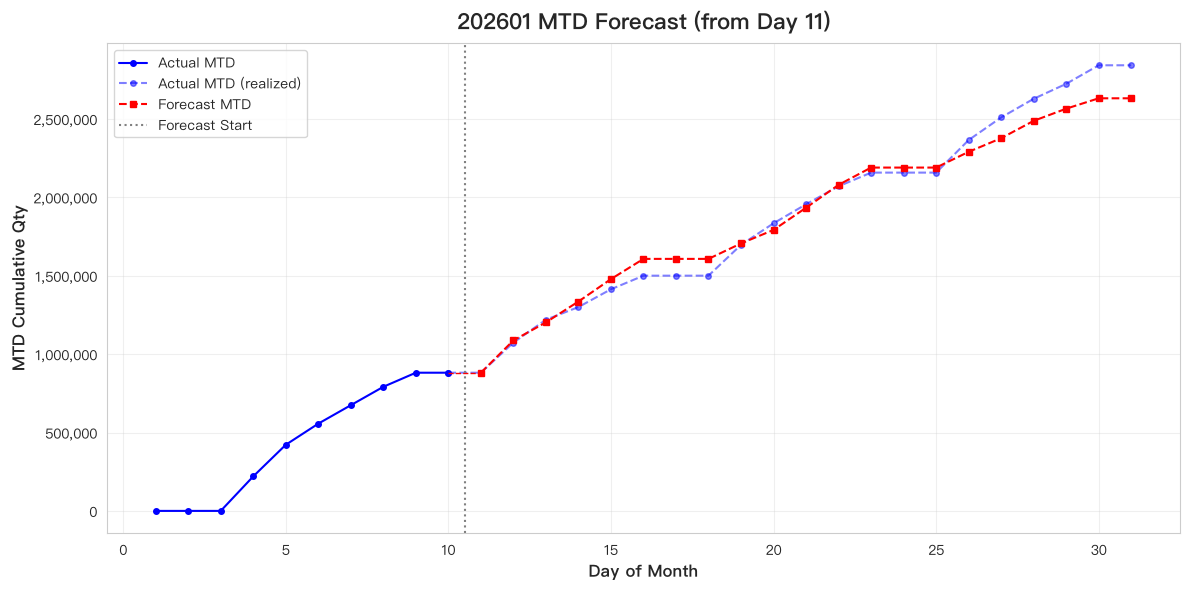

[预测参数] 锚点日期: 2026-01-15, 参考工作日数: 3, 各反推值: ['2,669,304', '2,562,262', '2,516,650'], 取中位数月末总量: 2,562,262


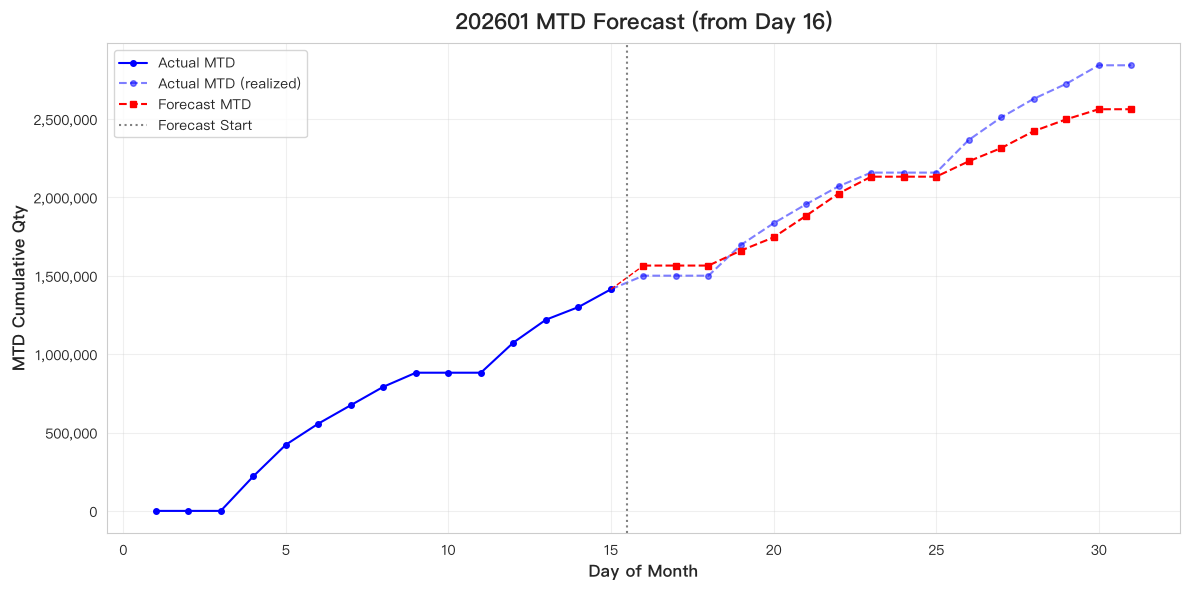

[预测参数] 锚点日期: 2026-01-20, 参考工作日数: 3, 各反推值: ['2,456,714', '2,618,000', '2,694,300'], 取中位数月末总量: 2,618,000


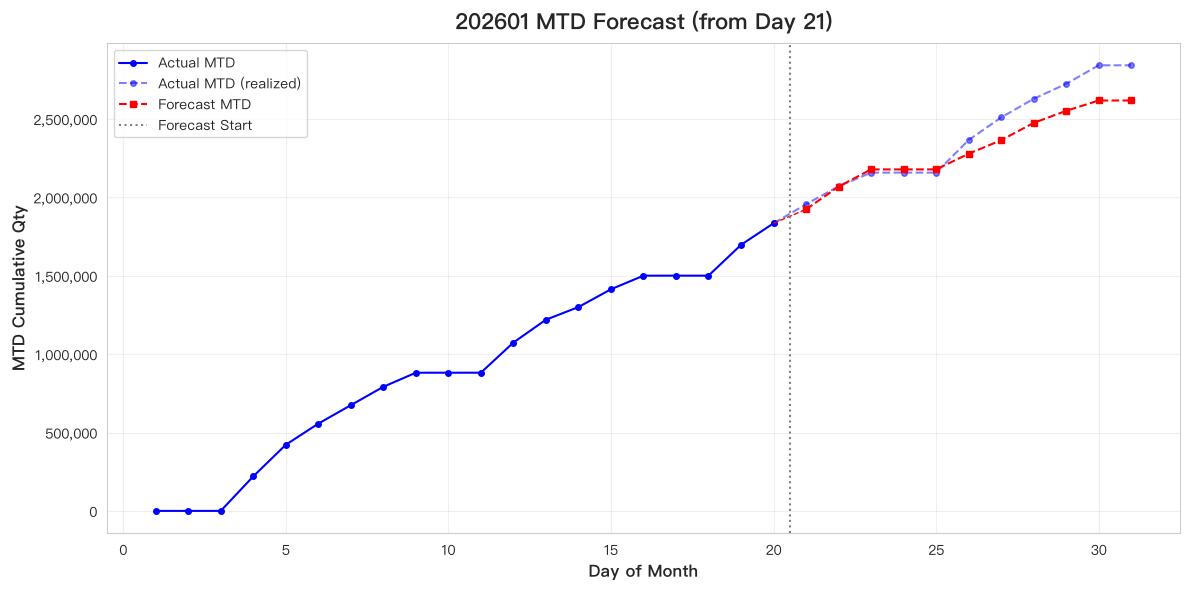

[预测参数] 锚点日期: 2026-01-25, 参考工作日数: 3, 各反推值: ['2,662,031', '2,620,446', '2,593,438'], 取中位数月末总量: 2,620,446


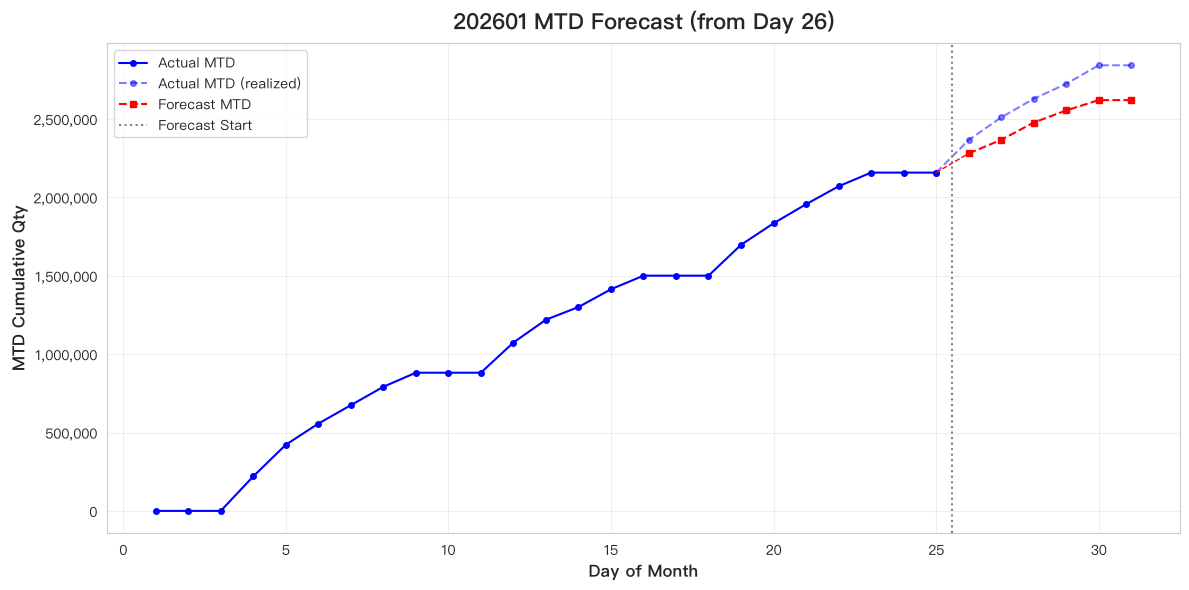

In [19]:
for i in [11,16,21,26]:
    forecast_start = date(2026, 1, i)
    
    forecast_df = forecast_mtd(
        df=df,
        target_ym=202601,
        forecast_start_date=forecast_start,
        blended_rhythm=blended_rhythm,
        lookback_wds=3
    )

    plot_forecast(df, 202601, forecast_df, forecast_start)

[预测参数] 锚点日期: 2026-01-10, 参考工作日数: 3, 各反推值: ['3,371,035', '2,632,060', '2,409,064'], 取中位数月末总量: 2,632,060
[预测参数] 锚点日期: 2026-01-11, 参考工作日数: 3, 各反推值: ['3,371,035', '2,632,060', '2,409,064'], 取中位数月末总量: 2,632,060
[预测参数] 锚点日期: 2026-01-12, 参考工作日数: 3, 各反推值: ['2,632,060', '2,409,064', '2,599,024'], 取中位数月末总量: 2,599,024
[预测参数] 锚点日期: 2026-01-13, 参考工作日数: 3, 各反推值: ['2,409,064', '2,599,024', '2,669,304'], 取中位数月末总量: 2,599,024
[预测参数] 锚点日期: 2026-01-14, 参考工作日数: 3, 各反推值: ['2,599,024', '2,669,304', '2,562,262'], 取中位数月末总量: 2,599,024
[预测参数] 锚点日期: 2026-01-15, 参考工作日数: 3, 各反推值: ['2,669,304', '2,562,262', '2,516,650'], 取中位数月末总量: 2,562,262
[预测参数] 锚点日期: 2026-01-16, 参考工作日数: 3, 各反推值: ['2,562,262', '2,516,650', '2,456,714'], 取中位数月末总量: 2,516,650
[预测参数] 锚点日期: 2026-01-17, 参考工作日数: 3, 各反推值: ['2,562,262', '2,516,650', '2,456,714'], 取中位数月末总量: 2,516,650
[预测参数] 锚点日期: 2026-01-18, 参考工作日数: 3, 各反推值: ['2,562,262', '2,516,650', '2,456,714'], 取中位数月末总量: 2,516,650
[预测参数] 锚点日期: 2026-01-19, 参考工作日数: 3, 各反推值: ['2,516,650', '2,456,714', '2,6

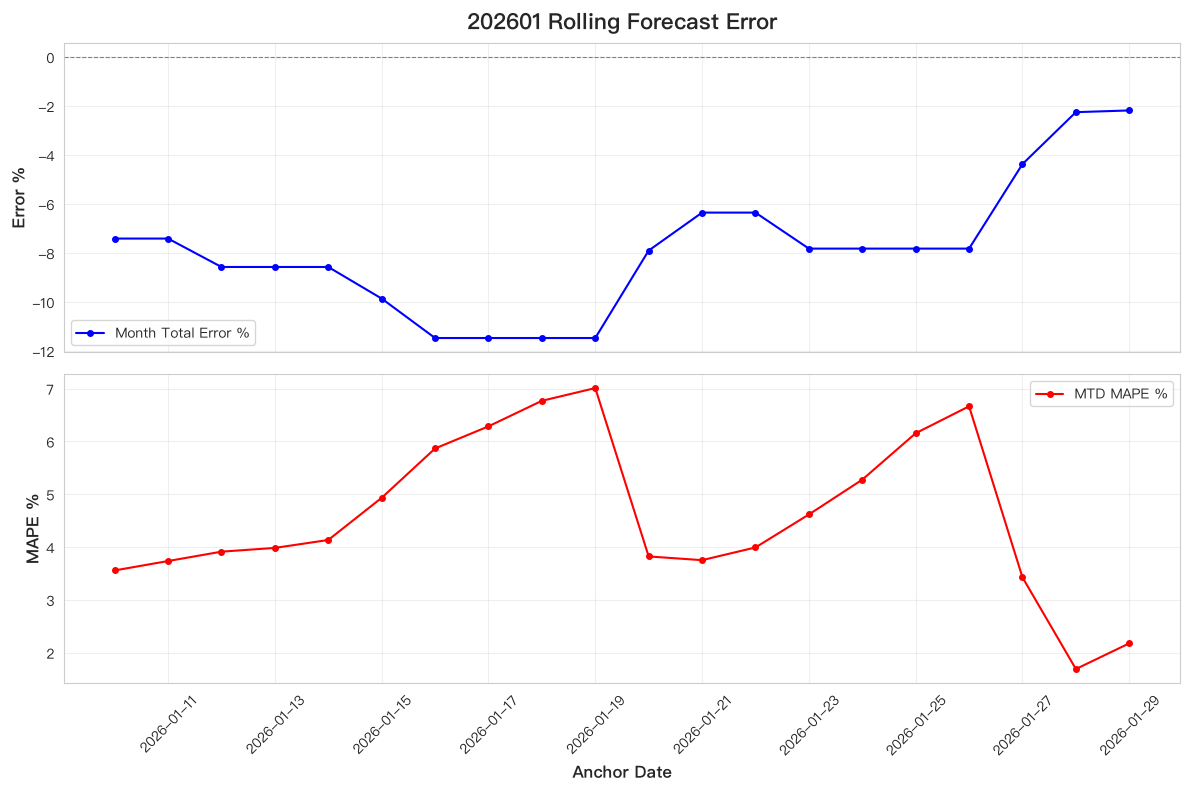

In [20]:
all_forecast_versions = {}
for i in range(11,31):
    forecast_start = date(2026, 1, i)
    forecast_df = forecast_mtd(
        df=df,
        target_ym=202601,
        forecast_start_date=forecast_start,
        blended_rhythm=blended_rhythm,
        lookback_wds=3
    )
    anchor_date = pd.Timestamp(forecast_start - timedelta(days=1))
    all_forecast_versions[anchor_date] = forecast_df

eval_df = evaluate_rolling_forecast(df, 202601, all_forecast_versions)
plot_rolling_error(eval_df, 202601)

### 202602

In [21]:
cal = build_calendar(2026, 2)
target_max_wd = cal[cal['is_workday']]['wd_seq'].max()
print(f"工作日天数：{target_max_wd}")

blended_rhythm = blend_rhythm(
    df=df,
    history_yms=[202502, 202402],
    weights=[0.3, 0.7],
    target_max_wd=target_max_wd
)
blended_rhythm

工作日天数：16
202502
    wd_seq    rhythm
0        1  0.069750
1        2  0.107587
2        3  0.129919
3        4  0.151540
4        5  0.230196
5        6  0.274646
6        7  0.321010
7        8  0.369475
8        9  0.402580
9       10  0.501565
10      11  0.557854
11      12  0.608858
12      13  0.654572
13      14  0.693127
14      15  0.798178
15      16  0.852821
16      17  0.907786
17      18  0.948539
18      19  1.000000
202402
    wd_seq    rhythm
0        1  0.113858
1        2  0.174301
2        3  0.239340
3        4  0.360799
4        5  0.425934
5        6  0.469278
6        7  0.482161
7        8  0.483173
8        9  0.548603
9       10  0.601247
10      11  0.637084
11      12  0.679019
12      13  0.711957
13      14  0.750517
14      15  0.850270
15      16  0.899772
16      17  0.946832
17      18  1.000000


1     0.100626
2     0.161697
3     0.231780
4     0.330417
5     0.394062
6     0.430810
7     0.450909
8     0.513621
9     0.583147
10    0.631427
11    0.679370
12    0.725207
13    0.813269
14    0.886340
15    0.940507
16    1.000000
dtype: float64

[预测参数] 锚点日期: 2026-02-10, 参考工作日数: 3, 各反推值: ['2,243,939', '2,556,915', '2,726,724'], 取中位数月末总量: 2,556,915


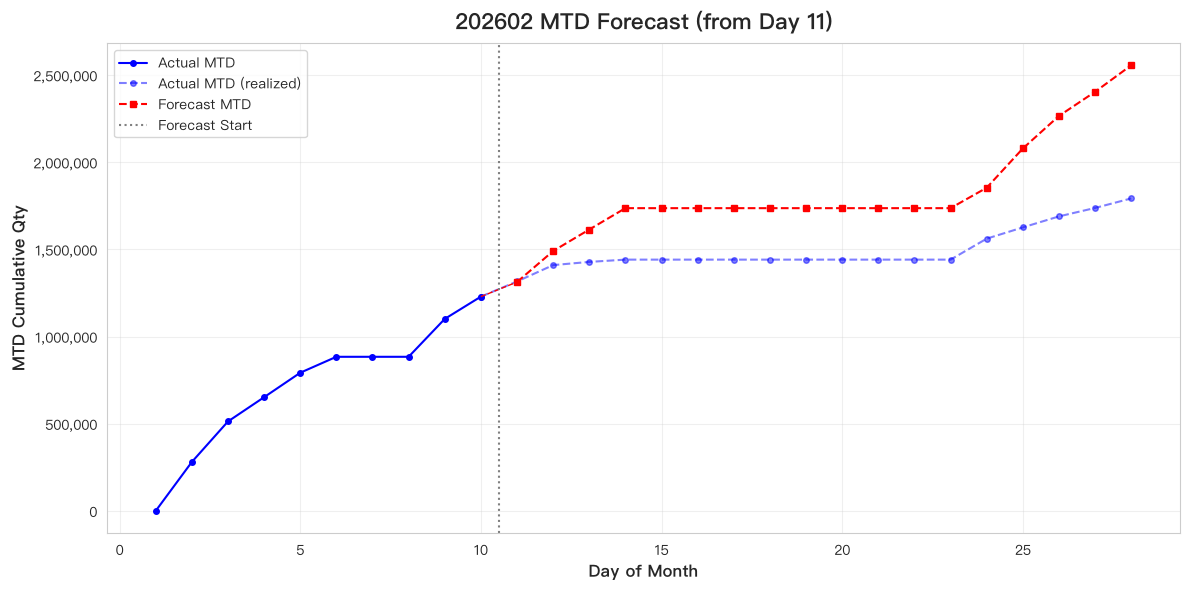

[预测参数] 锚点日期: 2026-02-15, 参考工作日数: 3, 各反推值: ['2,418,574', '2,262,630', '2,122,229'], 取中位数月末总量: 2,262,630


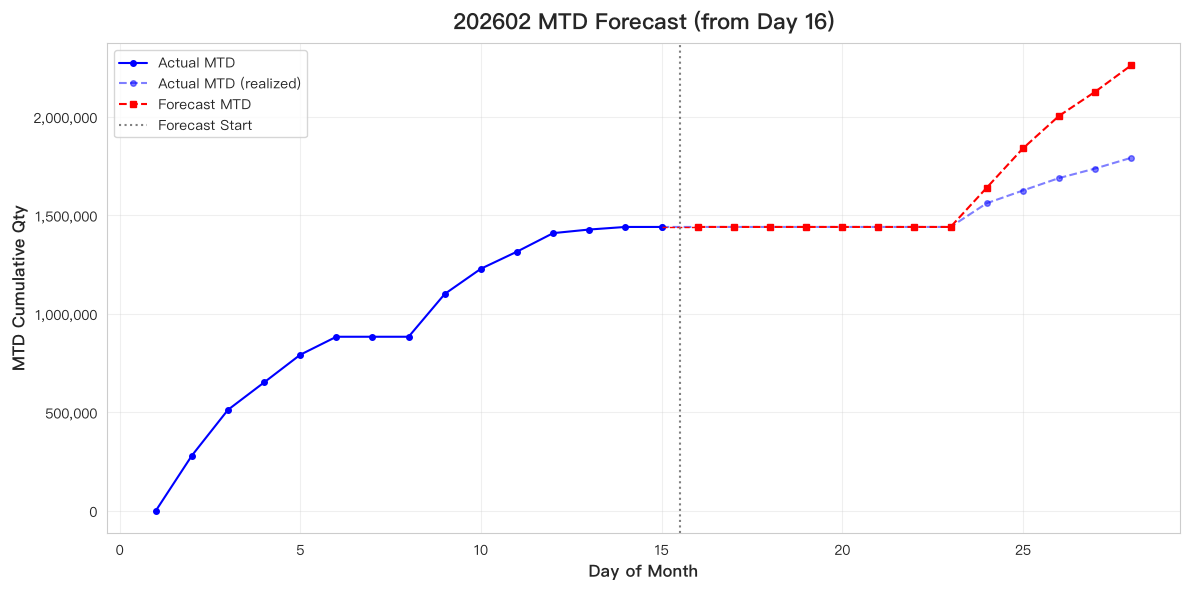

[预测参数] 锚点日期: 2026-02-20, 参考工作日数: 3, 各反推值: ['2,418,574', '2,262,630', '2,122,229'], 取中位数月末总量: 2,262,630


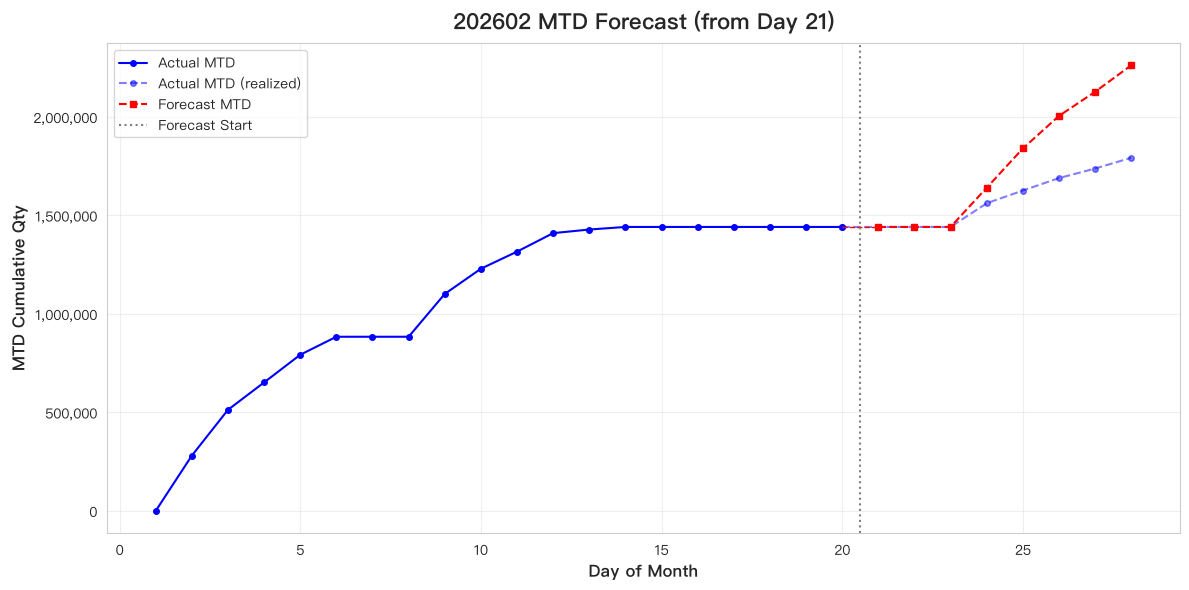

[预测参数] 锚点日期: 2026-02-25, 参考工作日数: 3, 各反推值: ['2,122,229', '2,154,012', '2,000,141'], 取中位数月末总量: 2,122,229


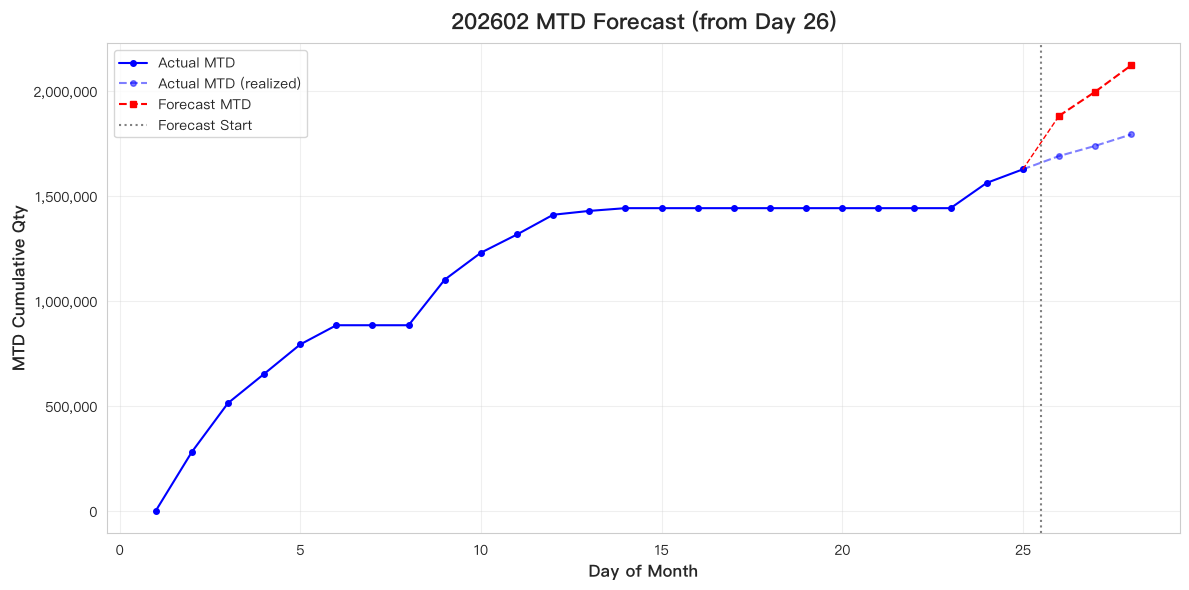

In [22]:
for i in [11,16,21,26]:
    forecast_start = date(2026, 2, i)
    
    forecast_df = forecast_mtd(
        df=df,
        target_ym=202602,
        forecast_start_date=forecast_start,
        blended_rhythm=blended_rhythm,
        lookback_wds=3
    )

    plot_forecast(df, 202602, forecast_df, forecast_start)

[预测参数] 锚点日期: 2026-02-10, 参考工作日数: 3, 各反推值: ['2,243,939', '2,556,915', '2,726,724'], 取中位数月末总量: 2,556,915
[预测参数] 锚点日期: 2026-02-11, 参考工作日数: 3, 各反推值: ['2,556,915', '2,726,724', '2,562,991'], 取中位数月末总量: 2,562,991
[预测参数] 锚点日期: 2026-02-12, 参考工作日数: 3, 各反推值: ['2,726,724', '2,562,991', '2,418,574'], 取中位数月末总量: 2,562,991
[预测参数] 锚点日期: 2026-02-13, 参考工作日数: 3, 各反推值: ['2,562,991', '2,418,574', '2,262,630'], 取中位数月末总量: 2,418,574
[预测参数] 锚点日期: 2026-02-14, 参考工作日数: 3, 各反推值: ['2,418,574', '2,262,630', '2,122,229'], 取中位数月末总量: 2,262,630
[预测参数] 锚点日期: 2026-02-15, 参考工作日数: 3, 各反推值: ['2,418,574', '2,262,630', '2,122,229'], 取中位数月末总量: 2,262,630
[预测参数] 锚点日期: 2026-02-16, 参考工作日数: 3, 各反推值: ['2,418,574', '2,262,630', '2,122,229'], 取中位数月末总量: 2,262,630
[预测参数] 锚点日期: 2026-02-17, 参考工作日数: 3, 各反推值: ['2,418,574', '2,262,630', '2,122,229'], 取中位数月末总量: 2,262,630
[预测参数] 锚点日期: 2026-02-18, 参考工作日数: 3, 各反推值: ['2,418,574', '2,262,630', '2,122,229'], 取中位数月末总量: 2,262,630
[预测参数] 锚点日期: 2026-02-19, 参考工作日数: 3, 各反推值: ['2,418,574', '2,262,630', '2,1

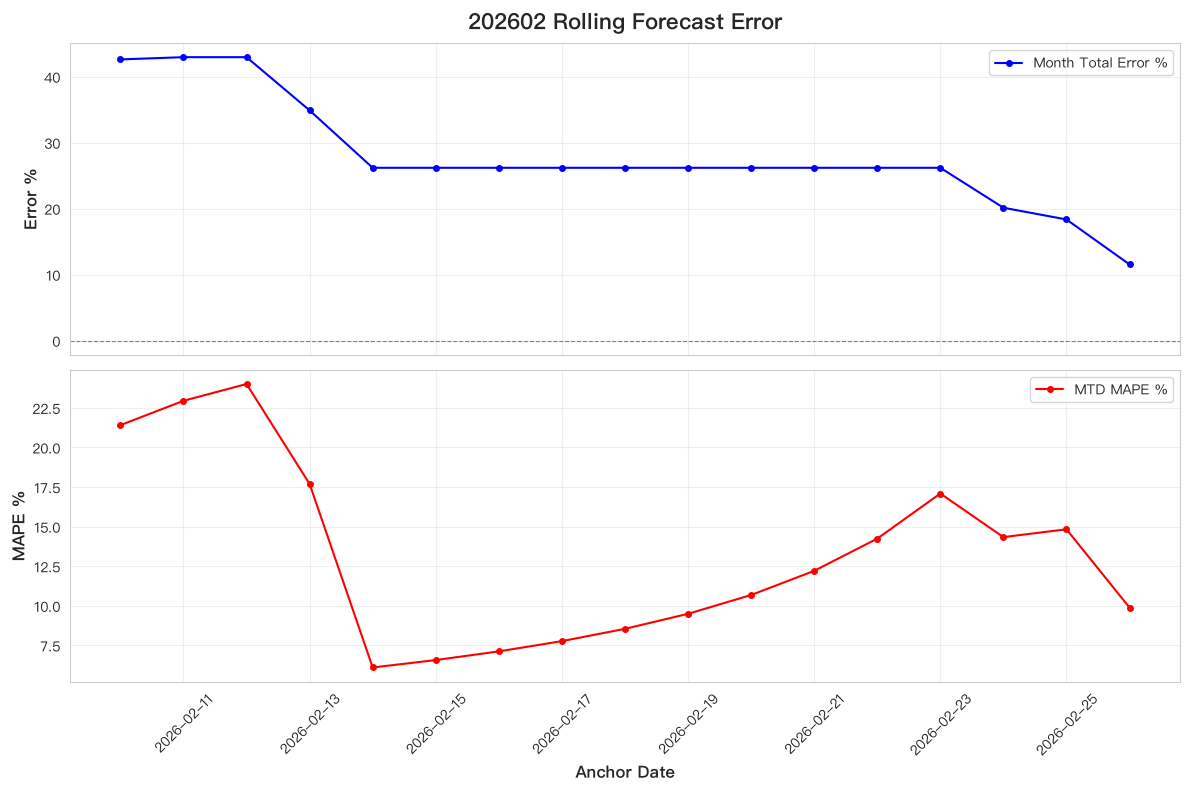

In [23]:
all_forecast_versions = {}
for i in range(11,28):
    forecast_start = date(2026, 2, i)
    forecast_df = forecast_mtd(
        df=df,
        target_ym=202602,
        forecast_start_date=forecast_start,
        blended_rhythm=blended_rhythm,
        lookback_wds=3
    )
    anchor_date = pd.Timestamp(forecast_start - timedelta(days=1))
    all_forecast_versions[anchor_date] = forecast_df

eval_df = evaluate_rolling_forecast(df, 202602, all_forecast_versions)
plot_rolling_error(eval_df, 202602)

### 202603

In [24]:
cal = build_calendar(2026, 3)
target_max_wd = cal[cal['is_workday']]['wd_seq'].max()
print(f"工作日天数：{target_max_wd}")

blended_rhythm = blend_rhythm(
    df=df,
    history_yms=[202503, 202403],
    weights=[0.7, 0.3],
    target_max_wd=target_max_wd
)
blended_rhythm

工作日天数：22
202503
    wd_seq    rhythm
0        1  0.093992
1        2  0.146571
2        3  0.180303
3        4  0.214945
4        5  0.239003
5        6  0.300473
6        7  0.343960
7        8  0.373418
8        9  0.405210
9       10  0.431572
10      11  0.506922
11      12  0.550230
12      13  0.584733
13      14  0.614141
14      15  0.640901
15      16  0.708529
16      17  0.755973
17      18  0.808514
18      19  0.845351
19      20  0.884717
20      21  1.000000
202403
    wd_seq    rhythm
0        1  0.047138
1        2  0.119216
2        3  0.156941
3        4  0.191145
4        5  0.249870
5        6  0.290916
6        7  0.371987
7        8  0.421715
8        9  0.457328
9       10  0.508318
10      11  0.539386
11      12  0.601954
12      13  0.651938
13      14  0.692835
14      15  0.723932
15      16  0.752707
16      17  0.822660
17      18  0.876165
18      19  0.912066
19      20  0.947970
20      21  1.000000


1     0.079935
2     0.135582
3     0.169968
4     0.202875
5     0.235700
6     0.284429
7     0.336722
8     0.376061
9     0.408298
10    0.440131
11    0.487106
12    0.540035
13    0.582524
14    0.617411
15    0.647103
16    0.681802
17    0.734686
18    0.786042
19    0.834032
20    0.869016
21    0.908279
22    1.000000
dtype: float64

[预测参数] 锚点日期: 2026-03-10, 参考工作日数: 3, 各反推值: ['2,392,910', '2,674,301', '2,586,961'], 取中位数月末总量: 2,586,961


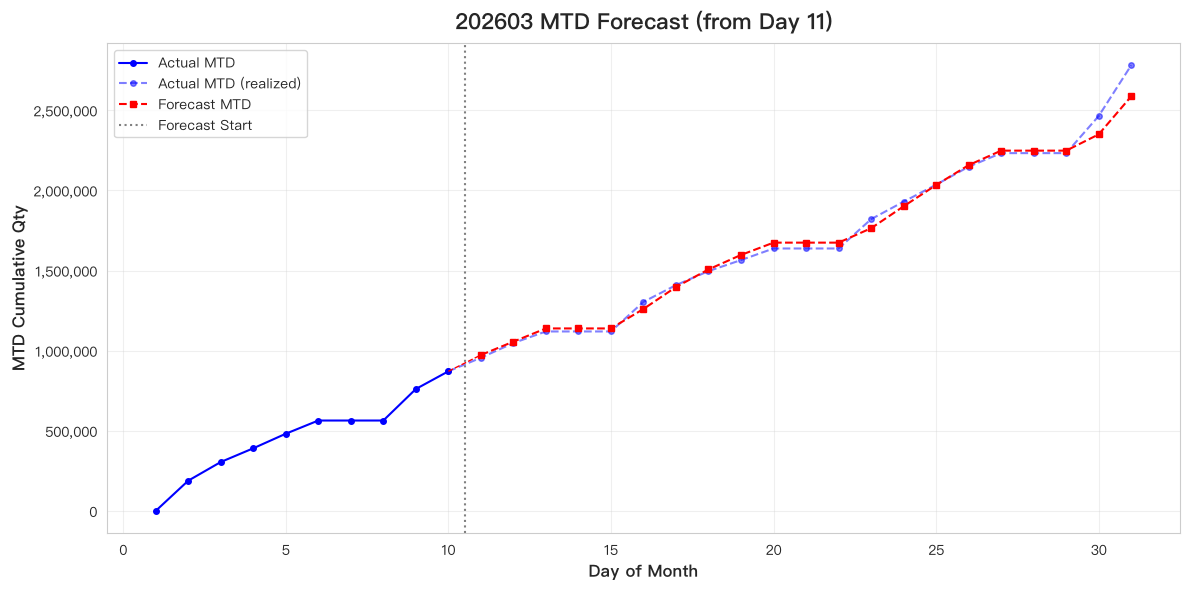

[预测参数] 锚点日期: 2026-03-15, 参考工作日数: 3, 各反推值: ['2,541,312', '2,565,751', '2,544,120'], 取中位数月末总量: 2,544,120


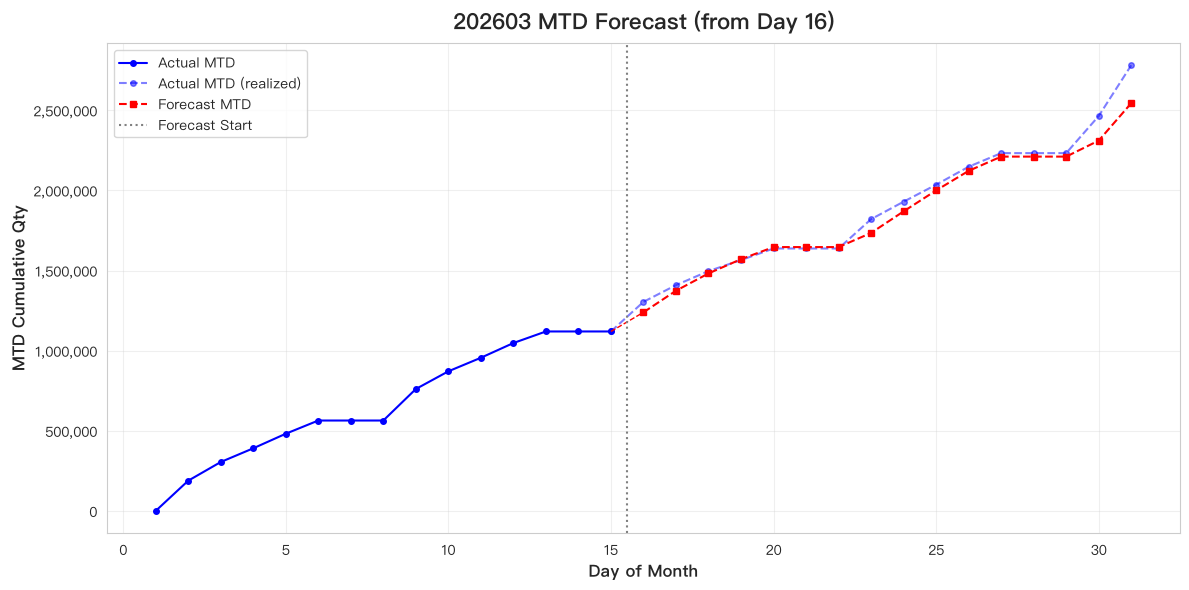

[预测参数] 锚点日期: 2026-03-20, 参考工作日数: 3, 各反推值: ['2,568,821', '2,535,081', '2,530,549'], 取中位数月末总量: 2,535,081


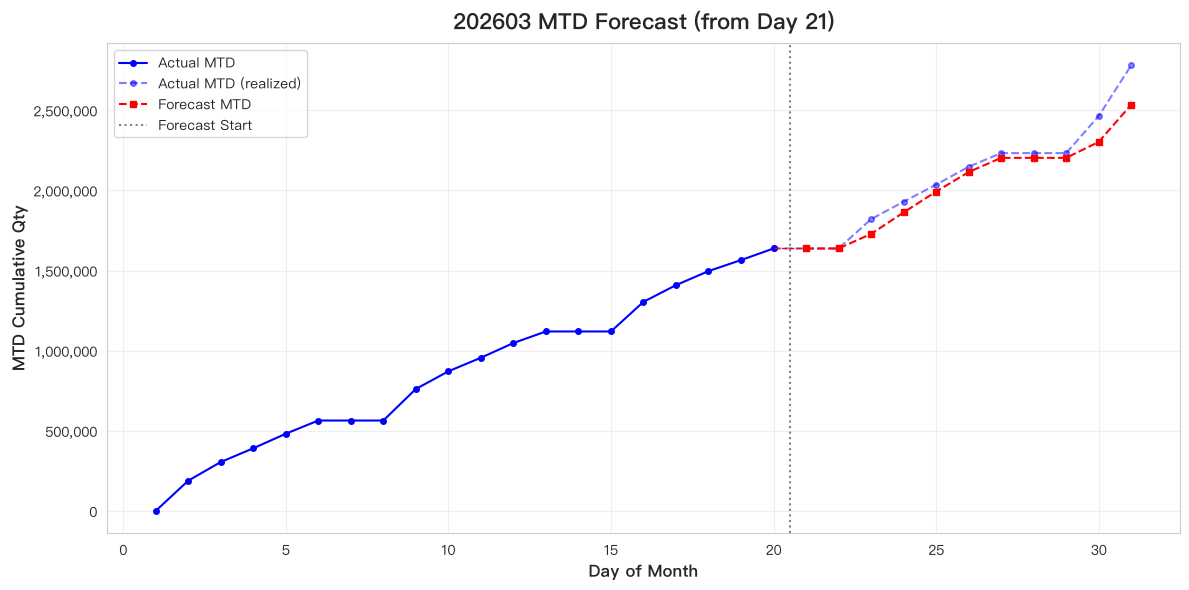

[预测参数] 锚点日期: 2026-03-25, 参考工作日数: 3, 各反推值: ['2,669,992', '2,626,398', '2,589,562'], 取中位数月末总量: 2,626,398


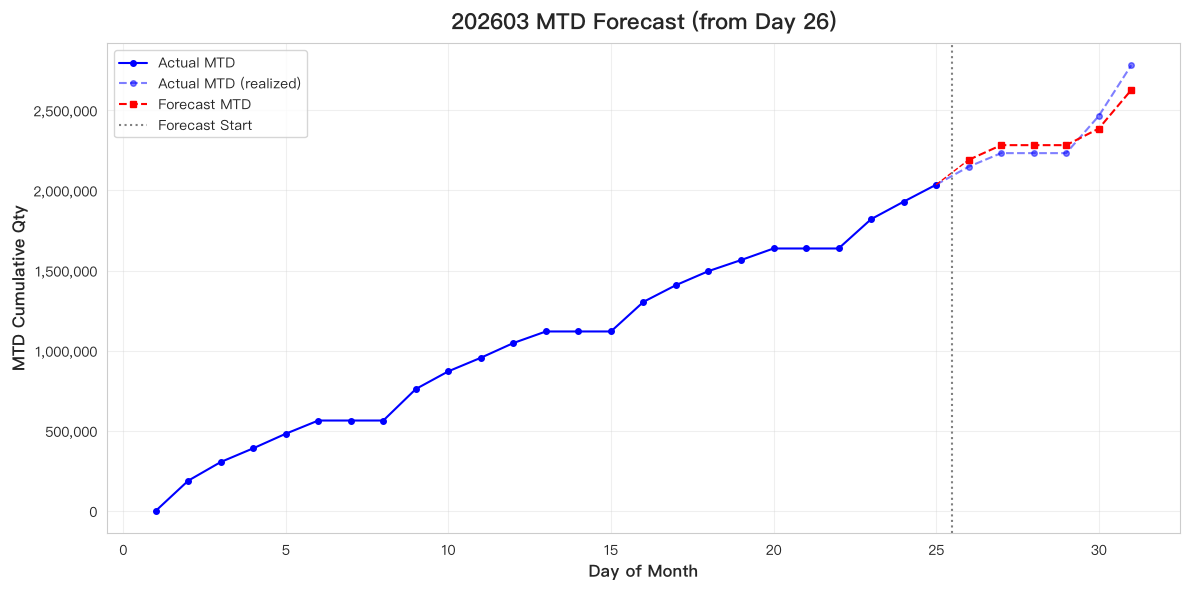

In [25]:
for i in [11,16,21,26]:
    forecast_start = date(2026, 3, i)
    
    forecast_df = forecast_mtd(
        df=df,
        target_ym=202603,
        forecast_start_date=forecast_start,
        blended_rhythm=blended_rhythm,
        lookback_wds=3
    )

    plot_forecast(df, 202603, forecast_df, forecast_start)

[预测参数] 锚点日期: 2026-03-10, 参考工作日数: 3, 各反推值: ['2,392,910', '2,674,301', '2,586,961'], 取中位数月末总量: 2,586,961
[预测参数] 锚点日期: 2026-03-11, 参考工作日数: 3, 各反推值: ['2,674,301', '2,586,961', '2,541,312'], 取中位数月末总量: 2,586,961
[预测参数] 锚点日期: 2026-03-12, 参考工作日数: 3, 各反推值: ['2,586,961', '2,541,312', '2,565,751'], 取中位数月末总量: 2,565,751
[预测参数] 锚点日期: 2026-03-13, 参考工作日数: 3, 各反推值: ['2,541,312', '2,565,751', '2,544,120'], 取中位数月末总量: 2,544,120
[预测参数] 锚点日期: 2026-03-14, 参考工作日数: 3, 各反推值: ['2,541,312', '2,565,751', '2,544,120'], 取中位数月末总量: 2,544,120
[预测参数] 锚点日期: 2026-03-15, 参考工作日数: 3, 各反推值: ['2,541,312', '2,565,751', '2,544,120'], 取中位数月末总量: 2,544,120
[预测参数] 锚点日期: 2026-03-16, 参考工作日数: 3, 各反推值: ['2,565,751', '2,544,120', '2,678,077'], 取中位数月末总量: 2,565,751
[预测参数] 锚点日期: 2026-03-17, 参考工作日数: 3, 各反推值: ['2,544,120', '2,678,077', '2,608,945'], 取中位数月末总量: 2,608,945
[预测参数] 锚点日期: 2026-03-18, 参考工作日数: 3, 各反推值: ['2,678,077', '2,608,945', '2,568,821'], 取中位数月末总量: 2,608,945
[预测参数] 锚点日期: 2026-03-19, 参考工作日数: 3, 各反推值: ['2,608,945', '2,568,821', '2,5

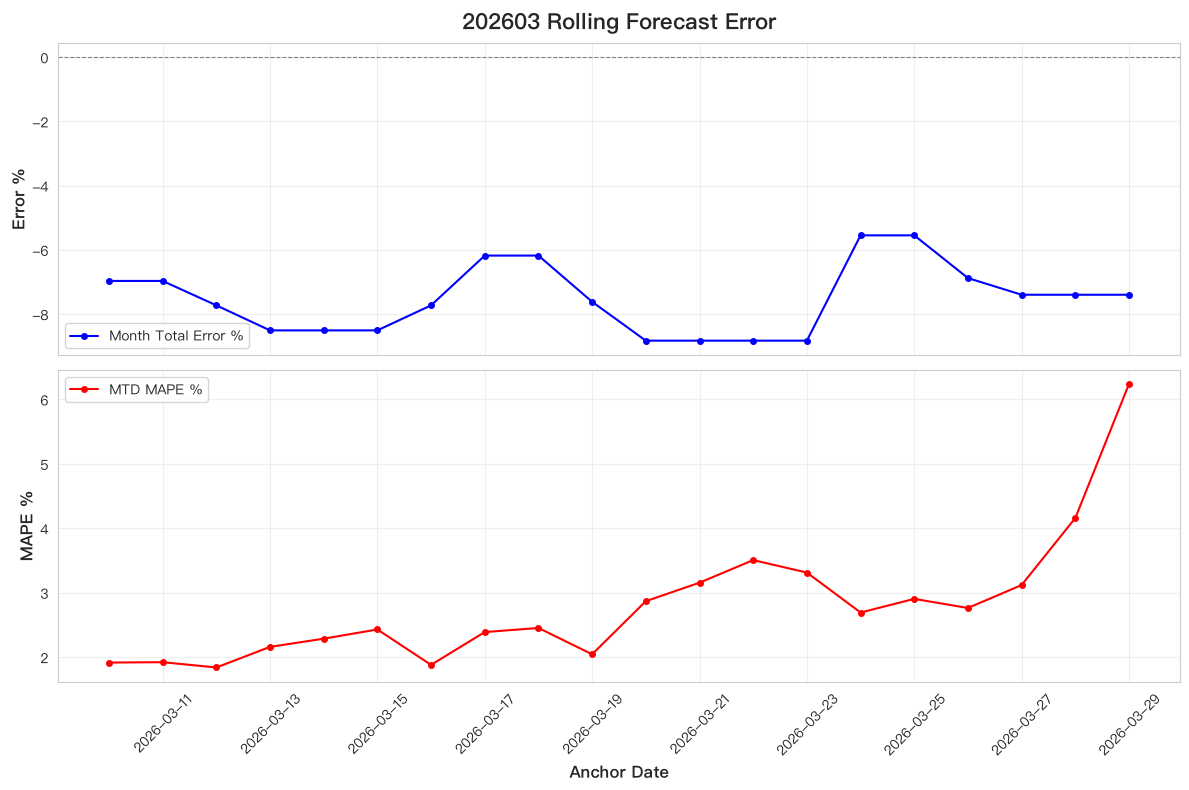

In [26]:
all_forecast_versions = {}
for i in range(11,31):
    forecast_start = date(2026, 3, i)
    forecast_df = forecast_mtd(
        df=df,
        target_ym=202603,
        forecast_start_date=forecast_start,
        blended_rhythm=blended_rhythm,
        lookback_wds=3
    )
    anchor_date = pd.Timestamp(forecast_start - timedelta(days=1))
    all_forecast_versions[anchor_date] = forecast_df

eval_df = evaluate_rolling_forecast(df, 202603, all_forecast_versions)
plot_rolling_error(eval_df, 202603)

### 202604

In [27]:
cal = build_calendar(2026, 4)
target_max_wd = cal[cal['is_workday']]['wd_seq'].max()
print(f"工作日天数：{target_max_wd}")

blended_rhythm = blend_rhythm(
    df=df,
    history_yms=[202504, 202404],
    weights=[0.7, 0.3],
    target_max_wd=target_max_wd
)
blended_rhythm

工作日天数：21
202504
    wd_seq    rhythm
0        1  0.076162
1        2  0.123422
2        3  0.147878
3        4  0.214832
4        5  0.257661
5        6  0.293384
6        7  0.327220
7        8  0.354343
8        9  0.422637
9       10  0.472566
10      11  0.510698
11      12  0.549030
12      13  0.576599
13      14  0.656445
14      15  0.711924
15      16  0.759980
16      17  0.802260
17      18  0.842027
18      19  0.890449
19      20  0.947194
20      21  0.975812
21      22  1.000000
202404
    wd_seq    rhythm
0        1  0.083110
1        2  0.132095
2        3  0.158826
3        4  0.205301
4        5  0.270723
5        6  0.311321
6        7  0.356135
7        8  0.394137
8        9  0.414916
9       10  0.485105
10      11  0.534046
11      12  0.569917
12      13  0.609938
13      14  0.644641
14      15  0.723483
15      16  0.775224
16      17  0.812505
17      18  0.851281
18      19  0.890763
19      20  0.932797
20      21  0.978868
21      22  1.000000


1     0.078247
2     0.127281
3     0.157244
4     0.219414
5     0.269017
6     0.308048
7     0.345011
8     0.385195
9     0.442723
10    0.494946
11    0.536499
12    0.572514
13    0.626382
14    0.693521
15    0.749805
16    0.795138
17    0.836909
18    0.883682
19    0.937642
20    0.975036
21    1.000000
dtype: float64

[预测参数] 锚点日期: 2026-04-10, 参考工作日数: 3, 各反推值: ['2,205,472', '2,241,407', '2,191,243'], 取中位数月末总量: 2,205,472


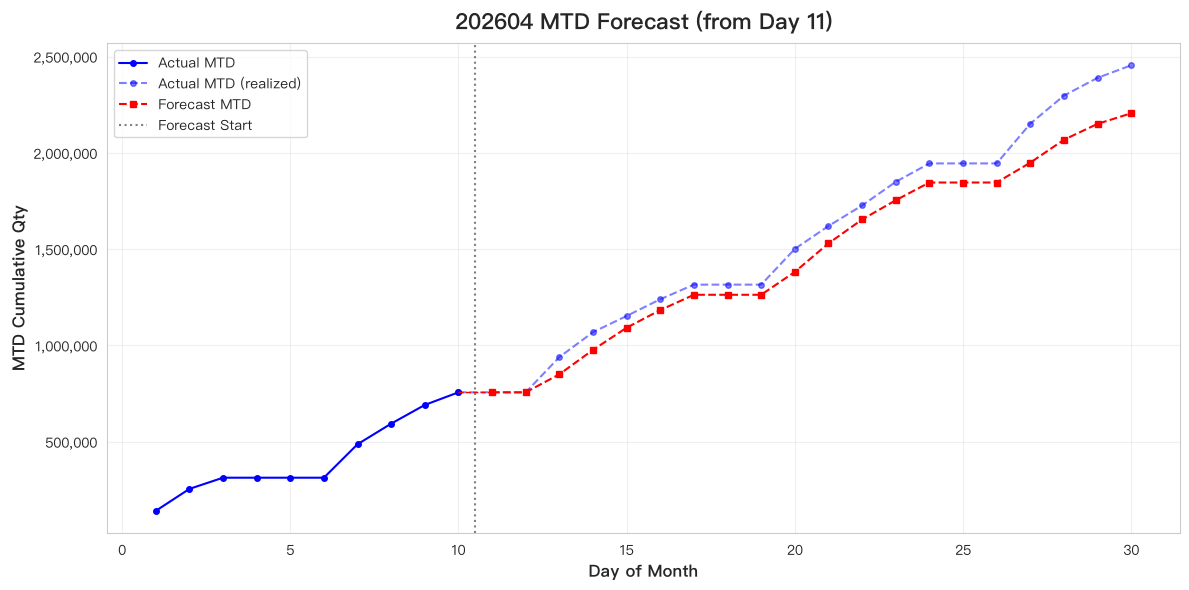

[预测参数] 锚点日期: 2026-04-15, 参考工作日数: 3, 各反推值: ['2,437,515', '2,413,437', '2,328,570'], 取中位数月末总量: 2,413,437


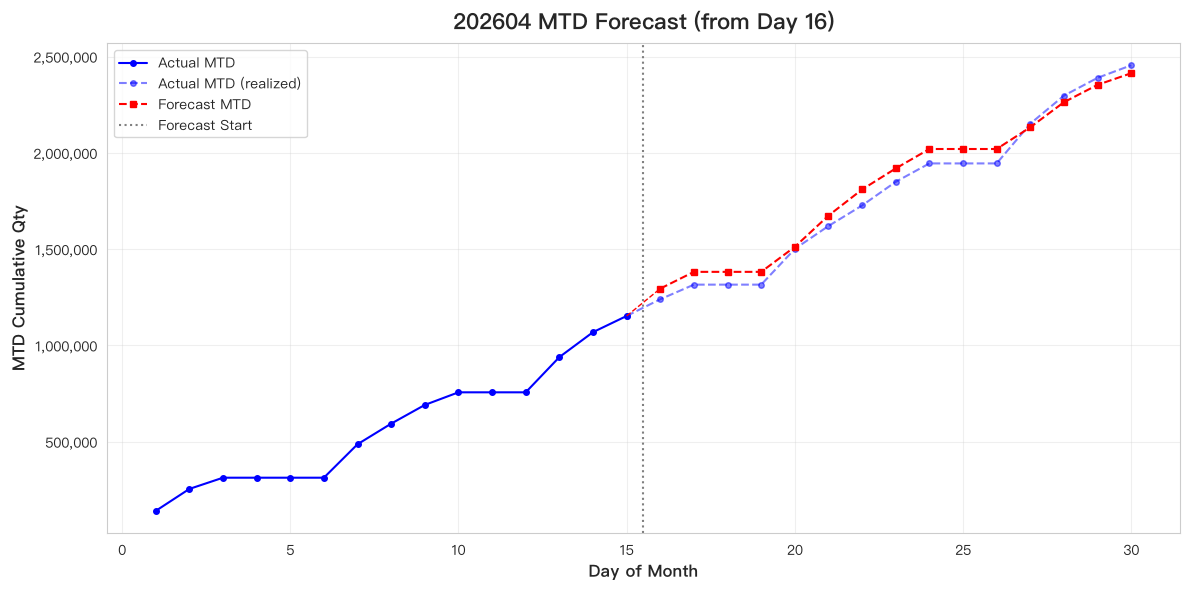

[预测参数] 锚点日期: 2026-04-20, 参考工作日数: 3, 各反推值: ['2,310,192', '2,297,476', '2,396,155'], 取中位数月末总量: 2,310,192


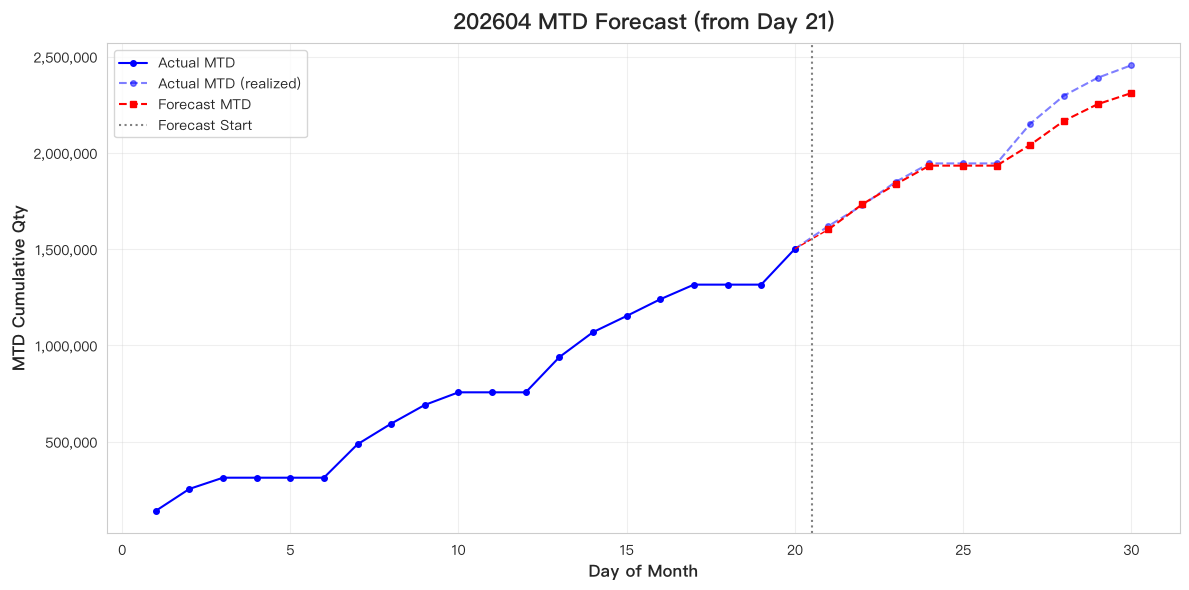

[预测参数] 锚点日期: 2026-04-25, 参考工作日数: 3, 各反推值: ['2,302,613', '2,325,907', '2,323,982'], 取中位数月末总量: 2,323,982


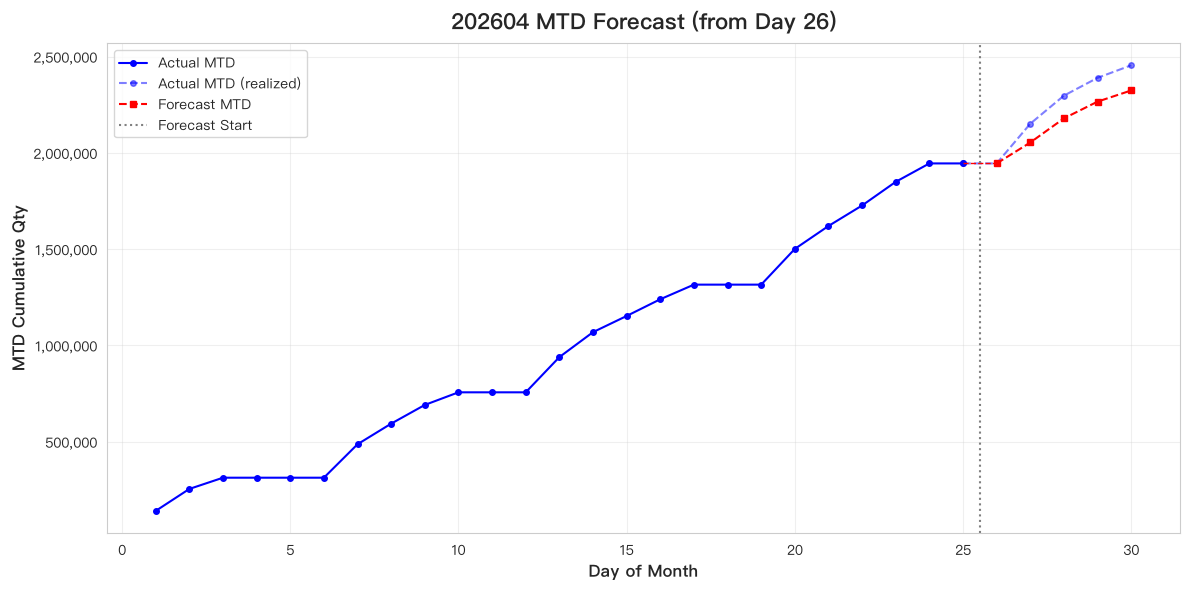

In [28]:
for i in [11,16,21,26]:
    forecast_start = date(2026, 4, i)
    
    forecast_df = forecast_mtd(
        df=df,
        target_ym=202604,
        forecast_start_date=forecast_start,
        blended_rhythm=blended_rhythm,
        lookback_wds=3
    )


    plot_forecast(df, 202604, forecast_df, forecast_start)

[预测参数] 锚点日期: 2026-04-10, 参考工作日数: 3, 各反推值: ['2,205,472', '2,241,407', '2,191,243'], 取中位数月末总量: 2,205,472
[预测参数] 锚点日期: 2026-04-11, 参考工作日数: 3, 各反推值: ['2,205,472', '2,241,407', '2,191,243'], 取中位数月末总量: 2,205,472
[预测参数] 锚点日期: 2026-04-12, 参考工作日数: 3, 各反推值: ['2,205,472', '2,241,407', '2,191,243'], 取中位数月末总量: 2,205,472
[预测参数] 锚点日期: 2026-04-13, 参考工作日数: 3, 各反推值: ['2,241,407', '2,191,243', '2,437,515'], 取中位数月末总量: 2,241,407
[预测参数] 锚点日期: 2026-04-14, 参考工作日数: 3, 各反推值: ['2,191,243', '2,437,515', '2,413,437'], 取中位数月末总量: 2,413,437
[预测参数] 锚点日期: 2026-04-15, 参考工作日数: 3, 各反推值: ['2,437,515', '2,413,437', '2,328,570'], 取中位数月末总量: 2,413,437
[预测参数] 锚点日期: 2026-04-16, 参考工作日数: 3, 各反推值: ['2,413,437', '2,328,570', '2,310,192'], 取中位数月末总量: 2,328,570
[预测参数] 锚点日期: 2026-04-17, 参考工作日数: 3, 各反推值: ['2,328,570', '2,310,192', '2,297,476'], 取中位数月末总量: 2,310,192
[预测参数] 锚点日期: 2026-04-18, 参考工作日数: 3, 各反推值: ['2,328,570', '2,310,192', '2,297,476'], 取中位数月末总量: 2,310,192
[预测参数] 锚点日期: 2026-04-19, 参考工作日数: 3, 各反推值: ['2,328,570', '2,310,192', '2,2

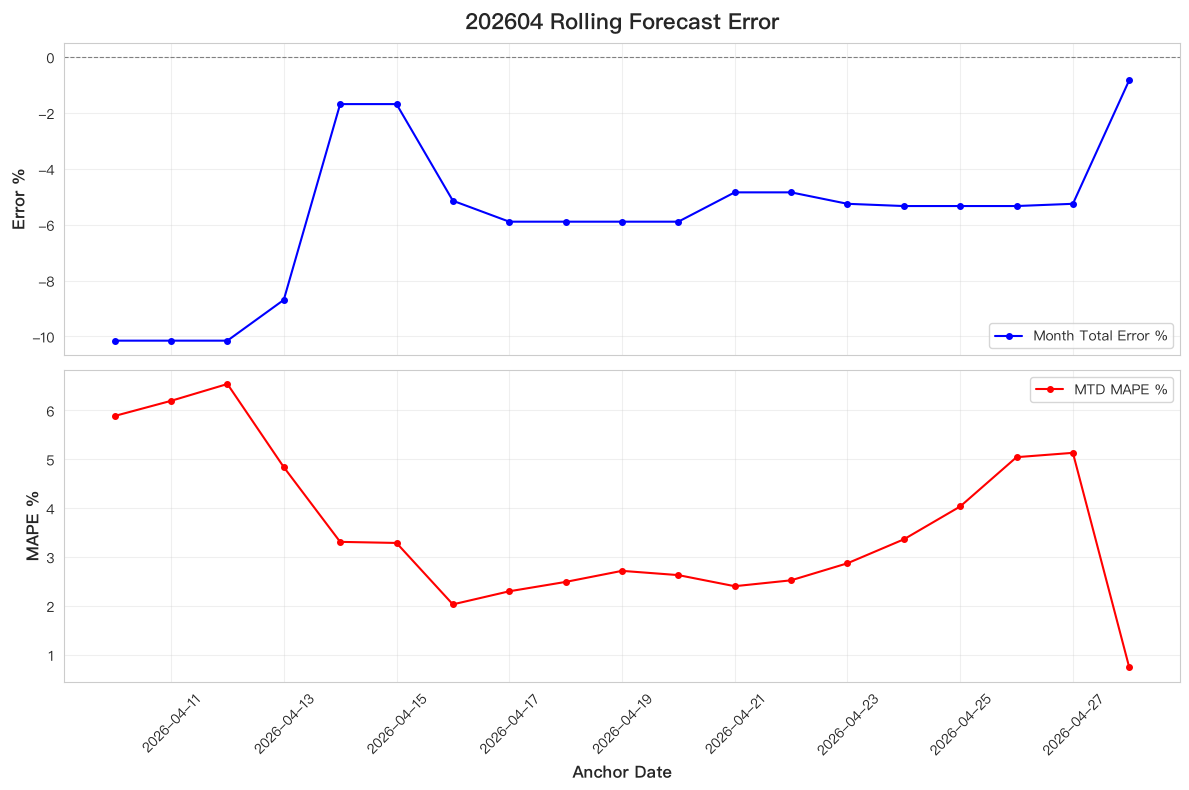

In [29]:
all_forecast_versions = {}
for i in range(11,30):
    forecast_start = date(2026, 4, i)
    forecast_df = forecast_mtd(
        df=df,
        target_ym=202604,
        forecast_start_date=forecast_start,
        blended_rhythm=blended_rhythm,
        lookback_wds=3
    )
    anchor_date = pd.Timestamp(forecast_start - timedelta(days=1))
    all_forecast_versions[anchor_date] = forecast_df

eval_df = evaluate_rolling_forecast(df, 202604, all_forecast_versions)
plot_rolling_error(eval_df, 202604)

In [30]:
# print("Daily预测误差(%)：")
# ((forecast_df.set_index('day_of_month')['predicted_mtd_qty'] / df[df['transdate']>=pd.to_datetime(forecast_start)]['mtd_qty'].values - 1) * 100).round(1)

# 优化：月度总量固定

+ 202604: 967181.9
+ 202603: 1032098.1
+ 202602: 784204.4
+ 202601: 1039816.5

In [31]:
def decompose_from_month_total(
    df: pd.DataFrame,
    target_ym: int,
    forecast_start_date: date,
    month_total: float,           # 已知的月末总量预测值
    blended_rhythm: pd.Series,    # blend_rhythm 生成的节奏曲线，index=wd_seq
) -> pd.DataFrame:
    """
    已知月末总量，按历史节奏拆解每天预测 MTD。

    拆解方式：
      - 锚点之后的剩余量 = month_total - anchor_mtd
      - 剩余量按历史节奏在锚点之后的相对分布拆分
      - 非工作日复制前一工作日的预测值（平台）

    返回 DataFrame：
        transdate, day_of_month, is_workday, wd_seq,
        predicted_mtd_qty, predicted_daily_qty
    """
    year, month = target_ym // 100, target_ym % 100
    cal = build_calendar(year, month)

    # 锚点：预测起始日前一天
    anchor_date = pd.Timestamp(forecast_start_date - timedelta(days=1))
    anchor_row = df[(df['bizym'] == target_ym) & (df['transdate'] == anchor_date)]
    if anchor_row.empty:
        raise ValueError(f"找不到锚点日期 {anchor_date.date()} 的数据")
    anchor_mtd = float(anchor_row['mtd_qty'].values[0])

    if month_total <= anchor_mtd:
        raise ValueError(
            f"月末总量预测值 {month_total:,.0f} 不能小于锚点 MTD {anchor_mtd:,.0f}"
        )

    # 锚点对应的工作日序号（非工作日取最近工作日序号）
    anchor_cal = cal[cal['transdate'] == anchor_date]
    if anchor_cal['is_workday'].values[0]:
        anchor_wd_seq = int(anchor_cal['wd_seq'].values[0])
    else:
        prev_wd_date = anchor_cal['prev_workday'].values[0]
        anchor_wd_seq = int(cal[cal['transdate'] == prev_wd_date]['wd_seq'].values[0])

    # 锚点已完成的累积占比
    anchor_rhythm = blended_rhythm.get(anchor_wd_seq, np.nan)
    if pd.isna(anchor_rhythm) or anchor_rhythm >= 1.0:
        raise ValueError(f"锚点 wd_seq={anchor_wd_seq} 的节奏值异常：{anchor_rhythm}")

    # 剩余数量
    remaining = month_total - anchor_mtd
    # 剩余空间（之后还有多少比例待完成）
    remaining_rhythm_span = 1.0 - anchor_rhythm

    print(f"[拆解参数] MTD实际数量: {anchor_mtd:,.0f}, 预测月末总量: {month_total:,.0f}, "
          f"预估剩余数量: {remaining:,.0f}, MTD进度: {anchor_rhythm:.1%}, "
          f"剩余空间: {remaining_rhythm_span:.1%}")

    # 预测日期范围
    result = cal[cal['transdate'] >= pd.Timestamp(forecast_start_date)].copy()

    # 工作日：剩余数量按相对节奏分配
    wd_mask = result['is_workday']
    r = result.loc[wd_mask, 'wd_seq'].map(blended_rhythm)
    result.loc[wd_mask, 'predicted_mtd_qty'] = (
        anchor_mtd + (r - anchor_rhythm) / remaining_rhythm_span * remaining
    )

    # 非工作日：前向填充（平台）
    result['predicted_mtd_qty'] = (
        result['predicted_mtd_qty'].ffill().fillna(anchor_mtd).round().astype(int)
    )

    # 每日销量 = MTD 差分，与锚点衔接
    all_mtd = [anchor_mtd] + result['predicted_mtd_qty'].tolist()
    result['predicted_daily_qty'] = [
        max(0, all_mtd[i] - all_mtd[i - 1]) for i in range(1, len(all_mtd))
    ]

    return result[['transdate', 'day_of_month', 'is_workday', 'wd_seq',
                    'predicted_mtd_qty', 'predicted_daily_qty']].reset_index(drop=True)

### 202601

In [32]:
cal = build_calendar(2026, 1)
target_max_wd = cal[cal['is_workday']]['wd_seq'].max()
print(f"工作日天数：{target_max_wd}")

blended_rhythm = blend_rhythm(
    df=df,
    history_yms=[202501, 202401],
    weights=[0.3, 0.7],
    target_max_wd=target_max_wd
)
blended_rhythm

工作日天数：21
202501
    wd_seq    rhythm
0        1  0.089457
1        2  0.130725
2        3  0.196615
3        4  0.260955
4        5  0.329262
5        6  0.399565
6        7  0.456474
7        8  0.544112
8        9  0.598999
9       10  0.649558
10      11  0.697467
11      12  0.738074
12      13  0.817473
13      14  0.869260
14      15  0.912431
15      16  0.952790
16      17  0.974293
17      18  0.990575
18      19  1.000000
202401
    wd_seq    rhythm
0        1  0.062425
1        2  0.085228
2        3  0.113483
3        4  0.163808
4        5  0.286316
5        6  0.356016
6        7  0.398317
7        8  0.434833
8        9  0.466222
9       10  0.518252
10      11  0.574747
11      12  0.613619
12      13  0.641957
13      14  0.671949
14      15  0.729819
15      16  0.780326
16      17  0.815788
17      18  0.852576
18      19  0.883993
19      20  0.936822
20      21  0.969292
21      22  1.000000


1     0.070535
2     0.098628
3     0.137992
4     0.200025
5     0.300761
6     0.365938
7     0.413189
8     0.456903
9     0.507451
10    0.561789
11    0.610795
12    0.648246
13    0.680952
14    0.734791
15    0.790185
16    0.832099
17    0.870225
18    0.903268
19    0.945342
20    0.974824
21    1.000000
dtype: float64

[拆解参数] MTD实际数量: 881,567, 预测月末总量: 1,039,816, 预估剩余数量: 158,250, MTD进度: 36.6%, 剩余空间: 63.4%


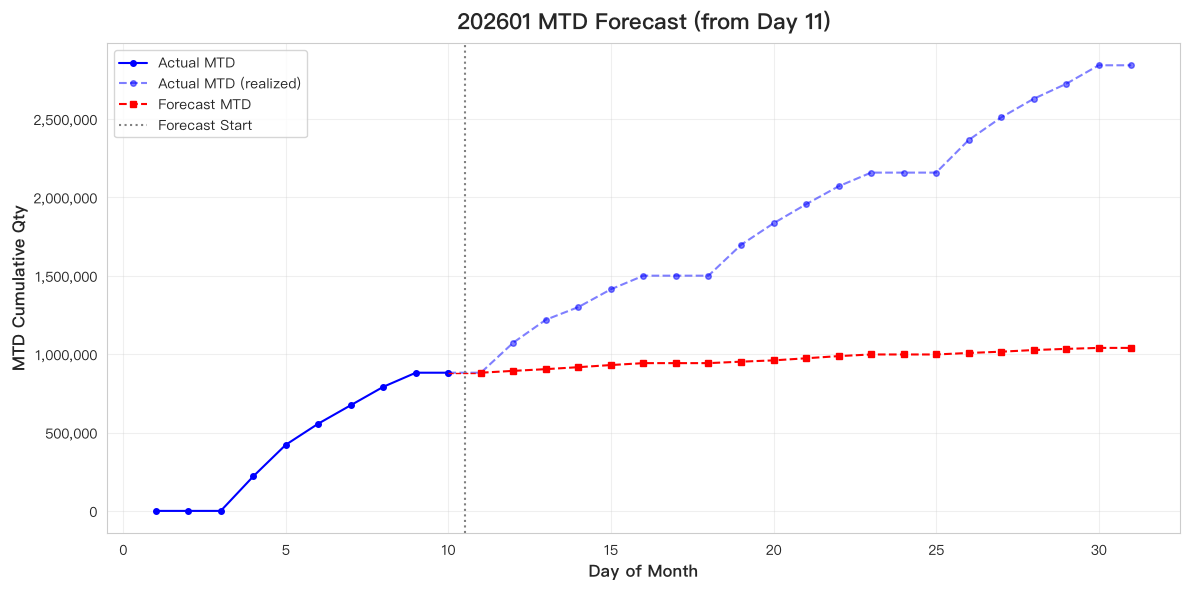

ValueError: 月末总量预测值 1,039,816 不能小于锚点 MTD 1,413,826

In [33]:
month_total = 1039816.5
for i in [11,16,21,26]:
    forecast_start = date(2026, 1, i)
    
    forecast_df = decompose_from_month_total(
        df=df,
        target_ym=202601,
        forecast_start_date=forecast_start,
        month_total=month_total,
        blended_rhythm=blended_rhythm,
    )

    plot_forecast(df, 202601, forecast_df, forecast_start)

In [ ]:
all_forecast_versions = {}
month_total = 1039816.5
for i in range(11,31):
    forecast_start = date(2026, 1, i)
    forecast_df = decompose_from_month_total(
        df=df,
        target_ym=202601,
        forecast_start_date=forecast_start,
        month_total=month_total,
        blended_rhythm=blended_rhythm,
    )
    anchor_date = pd.Timestamp(forecast_start - timedelta(days=1))
    all_forecast_versions[anchor_date] = forecast_df

eval_df = evaluate_rolling_forecast(df, 202601, all_forecast_versions)
plot_rolling_error(eval_df, 202601)

### 202602

In [ ]:
cal = build_calendar(2026, 2)
target_max_wd = cal[cal['is_workday']]['wd_seq'].max()
print(f"工作日天数：{target_max_wd}")

blended_rhythm = blend_rhythm(
    df=df,
    history_yms=[202502, 202402],
    weights=[0.3, 0.7],
    target_max_wd=target_max_wd
)
blended_rhythm

In [ ]:
month_total = 784204.4
for i in [11,16,21,26]:
    forecast_start = date(2026, 2, i)
    
    forecast_df = decompose_from_month_total(
        df=df,
        target_ym=202602,
        forecast_start_date=forecast_start,
        month_total=month_total,
        blended_rhythm=blended_rhythm,
    )

    plot_forecast(df, 202602, forecast_df, forecast_start)

In [ ]:
all_forecast_versions = {}
month_total = 784204.4
for i in range(11,28):
    forecast_start = date(2026, 2, i)
    forecast_df = decompose_from_month_total(
        df=df,
        target_ym=202602,
        forecast_start_date=forecast_start,
        month_total=month_total,
        blended_rhythm=blended_rhythm,
    )
    anchor_date = pd.Timestamp(forecast_start - timedelta(days=1))
    all_forecast_versions[anchor_date] = forecast_df

eval_df = evaluate_rolling_forecast(df, 202602, all_forecast_versions)
plot_rolling_error(eval_df, 202602)

### 202603

In [ ]:
cal = build_calendar(2026, 3)
target_max_wd = cal[cal['is_workday']]['wd_seq'].max()
print(f"工作日天数：{target_max_wd}")

blended_rhythm = blend_rhythm(
    df=df,
    history_yms=[202503, 202403],
    weights=[0.7, 0.3],
    target_max_wd=target_max_wd
)
blended_rhythm

In [ ]:
month_total = 1032098.1
for i in [11,16,21,26]:
    forecast_start = date(2026, 3, i)
    
    forecast_df = decompose_from_month_total(
        df=df,
        target_ym=202603,
        forecast_start_date=forecast_start,
        month_total=month_total,
        blended_rhythm=blended_rhythm,
    )

    plot_forecast(df, 202603, forecast_df, forecast_start)

In [ ]:
all_forecast_versions = {}
month_total = 1032098.1
for i in range(11,31):
    forecast_start = date(2026, 3, i)
    forecast_df = decompose_from_month_total(
        df=df,
        target_ym=202603,
        forecast_start_date=forecast_start,
        month_total=month_total,
        blended_rhythm=blended_rhythm,
    )
    anchor_date = pd.Timestamp(forecast_start - timedelta(days=1))
    all_forecast_versions[anchor_date] = forecast_df

eval_df = evaluate_rolling_forecast(df, 202603, all_forecast_versions)
plot_rolling_error(eval_df, 202603)

### 202604

In [ ]:
cal = build_calendar(2026, 4)
target_max_wd = cal[cal['is_workday']]['wd_seq'].max()
print(f"工作日天数：{target_max_wd}")

blended_rhythm = blend_rhythm(
    df=df,
    history_yms=[202504, 202404],
    weights=[0.7, 0.3],
    target_max_wd=target_max_wd
)
blended_rhythm

In [ ]:
month_total = 967181.9
for i in [11,16,21,26]:
    forecast_start = date(2026, 4, i)
    
    forecast_df = decompose_from_month_total(
        df=df,
        target_ym=202604,
        forecast_start_date=forecast_start,
        month_total=month_total,
        blended_rhythm=blended_rhythm,
    )

    plot_forecast(df, 202604, forecast_df, forecast_start)

In [ ]:
all_forecast_versions = {}
month_total = 967181.9

for i in range(11,30):
    forecast_start = date(2026, 4, i)
    forecast_df = decompose_from_month_total(
        df=df,
        target_ym=202604,
        forecast_start_date=forecast_start,
        month_total=month_total,
        blended_rhythm=blended_rhythm,
    )
    anchor_date = pd.Timestamp(forecast_start - timedelta(days=1))
    all_forecast_versions[anchor_date] = forecast_df

eval_df = evaluate_rolling_forecast(df, 202604, all_forecast_versions)
plot_rolling_error(eval_df, 202604)